In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib as mpl
import numpy as np
from scipy.interpolate import interp1d
import re
mpl.rcParams['svg.fonttype'] = 'none'
from scipy.optimize import root_scalar
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import glob
import matplotlib.cm as cm
import seaborn as sns
from scipy.stats import gaussian_kde
from math import sqrt, pi
import pickle
from collections import defaultdict
from itertools import product
import gurobipy as gp
from gurobipy import GRB
import itertools
from datetime import datetime, timedelta  
from glob import glob

## 데이터 불러오기

### 데이터 전처리

In [9]:
# 헤더명 매핑
mapping = {
    'Periodo': 'Time Period',
    'Fecha': 'Date',
    'Precio Compra/Venta': 'Price',
    'Potencia Compra/Venta': 'Amount',
    'Tipo Oferta': 'GC'
}

# 마지막 점(.)만 남기기
pattern = r'\.(?=[^.]*\.)'

# 데이터 저장된 폴더
data_dir = "rdcdata"

# 날짜 범위
start_date = datetime(2025, 4, 20)
end_date   = datetime(2025, 7, 28)
date_list  = pd.date_range(start_date, end_date, freq="D")

for date in date_list:
    date_str = date.strftime("%Y%m%d")
    in_file  = os.path.join(data_dir, f"curva_pbc_{date_str}.1")
    mid_file = os.path.join(data_dir, f"curve_{date_str}.csv")
    out_file = os.path.join(data_dir, f"filteredcurve_{date_str}.csv")

    if os.path.isfile(in_file):
        # 1) 원본 읽기
        df = pd.read_csv(in_file, sep=';', encoding='latin-1', skiprows=2)
        df = df.rename(columns=mapping)
        df.to_csv(mid_file, index=False, encoding='utf-8-sig')
        print(f"✔ Converted: {in_file} → {mid_file}")

        # 2) 숫자 문자열 정리
        df = pd.read_csv(mid_file, sep=',', encoding='utf-8-sig')
        df['Price']  = (df['Price'].astype(str)
                                  .str.replace(',', '.', regex=False)
                                  .apply(lambda s: re.sub(pattern, '', s)))
        df['Amount'] = (df['Amount'].astype(str)
                                  .str.replace(',', '.', regex=False)
                                  .apply(lambda s: re.sub(pattern, '', s)))
        df['Price']  = pd.to_numeric(df['Price'], errors='coerce')
        df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')

        # 3) 최종 저장
        df.to_csv(out_file, sep=',', index=False, encoding='utf-8-sig')
        print(f"✔ Cleaned: {mid_file} → {out_file}")

    else:
        print(f"⚠ File not found: {in_file}")


✔ Converted: rdcdata\curva_pbc_20250420.1 → rdcdata\curve_20250420.csv
✔ Cleaned: rdcdata\curve_20250420.csv → rdcdata\filteredcurve_20250420.csv
✔ Converted: rdcdata\curva_pbc_20250421.1 → rdcdata\curve_20250421.csv
✔ Cleaned: rdcdata\curve_20250421.csv → rdcdata\filteredcurve_20250421.csv
✔ Converted: rdcdata\curva_pbc_20250422.1 → rdcdata\curve_20250422.csv
✔ Cleaned: rdcdata\curve_20250422.csv → rdcdata\filteredcurve_20250422.csv
✔ Converted: rdcdata\curva_pbc_20250423.1 → rdcdata\curve_20250423.csv
✔ Cleaned: rdcdata\curve_20250423.csv → rdcdata\filteredcurve_20250423.csv
✔ Converted: rdcdata\curva_pbc_20250424.1 → rdcdata\curve_20250424.csv
✔ Cleaned: rdcdata\curve_20250424.csv → rdcdata\filteredcurve_20250424.csv
✔ Converted: rdcdata\curva_pbc_20250425.1 → rdcdata\curve_20250425.csv
✔ Cleaned: rdcdata\curve_20250425.csv → rdcdata\filteredcurve_20250425.csv
✔ Converted: rdcdata\curva_pbc_20250426.1 → rdcdata\curve_20250426.csv
✔ Cleaned: rdcdata\curve_20250426.csv → rdcdata\filte

수요 공급곡선 그려보기

In [2]:
def load_curves_from_path(file_path, period):
    """시나리오 파일 경로 + 시간(period)로 공급/수요 곡선 반환"""
    df = pd.read_csv(file_path, sep=',', encoding='utf-8-sig')

    mask   = df['Time Period'] == period
    supply = df[mask & (df['GC'] == 'V')]
    demand = df[mask & (df['GC'] == 'C')]
    if supply.empty or demand.empty:
        return None

    # 공급 곡선 집계
    s_agg = (supply.groupby('Price')['Amount'].sum()
                   .reset_index().sort_values('Price'))
    s_agg['CumulQty'] = s_agg['Amount'].cumsum()

    # 수요 곡선 집계
    d_agg = (demand.groupby('Price')['Amount'].sum()
                   .reset_index().sort_values('Price'))
    d_agg['CumulQty'] = d_agg['Amount'][::-1].cumsum()[::-1]

    # Price grid 기준 보간
    pmin = min(s_agg['Price'].min(), d_agg['Price'].min())
    pmax = max(s_agg['Price'].max(), d_agg['Price'].max())
    price_grid  = np.linspace(pmin, pmax, 500)

    s_func = interp1d(s_agg['Price'], s_agg['CumulQty'],
                      kind='previous', bounds_error=False,
                      fill_value=(0, s_agg['CumulQty'].iloc[-1]))
    d_func = interp1d(d_agg['Price'], d_agg['CumulQty'],
                      kind='previous', bounds_error=False,
                      fill_value=(d_agg['CumulQty'].iloc[0], 0))

    supply_vals = s_func(price_grid)
    demand_vals = d_func(price_grid)
    return price_grid, supply_vals, demand_vals

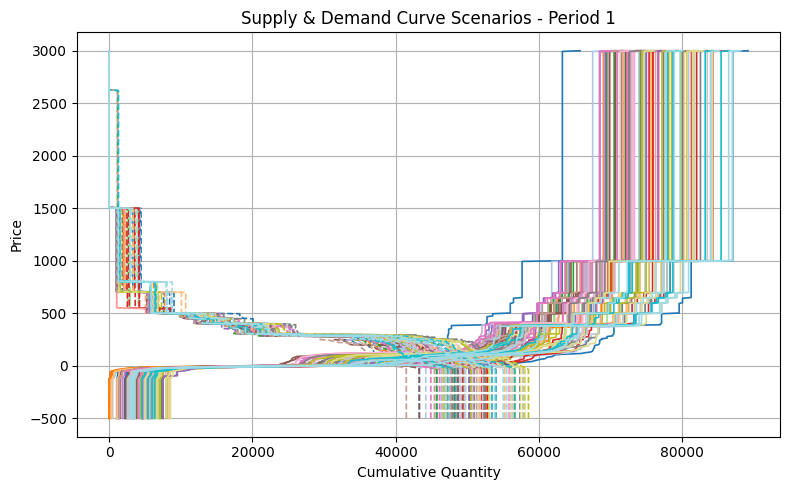

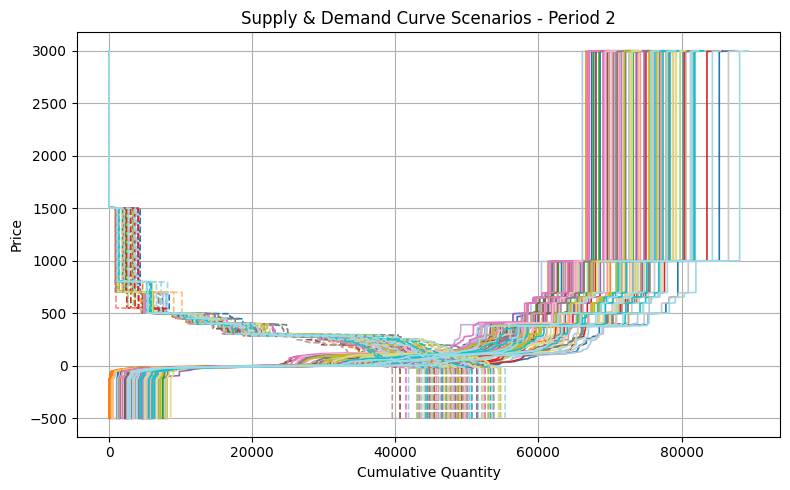

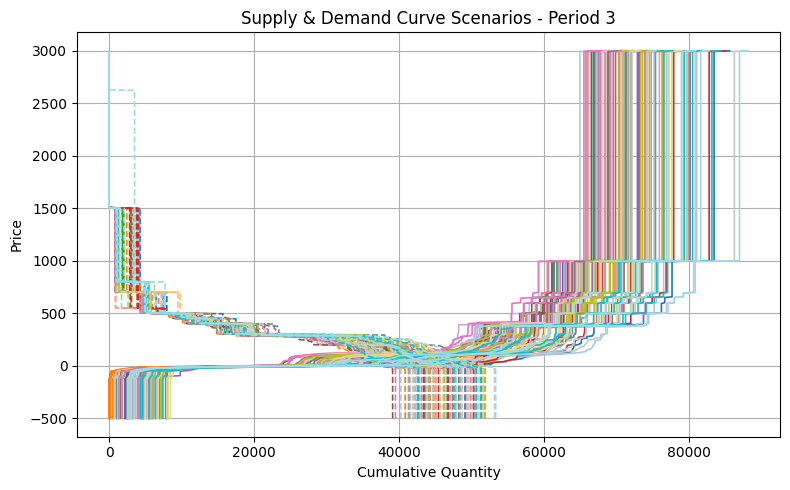

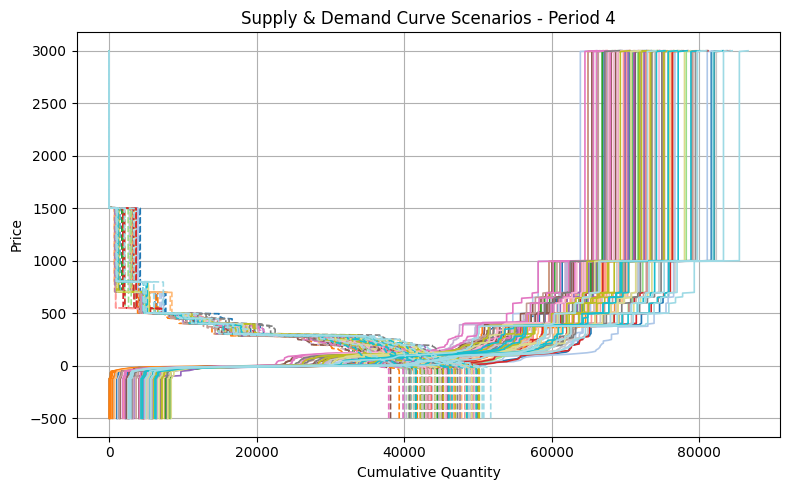

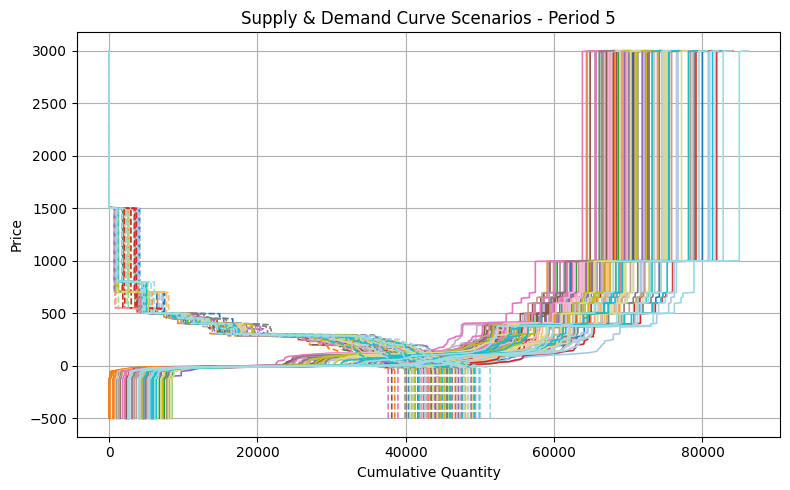

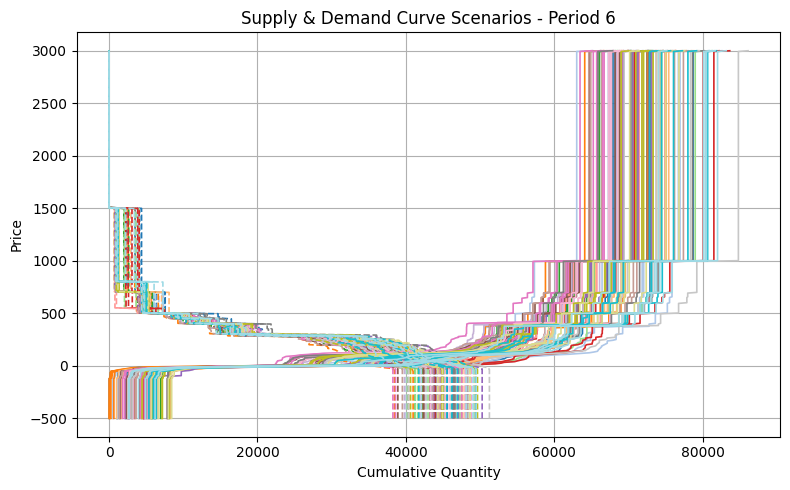

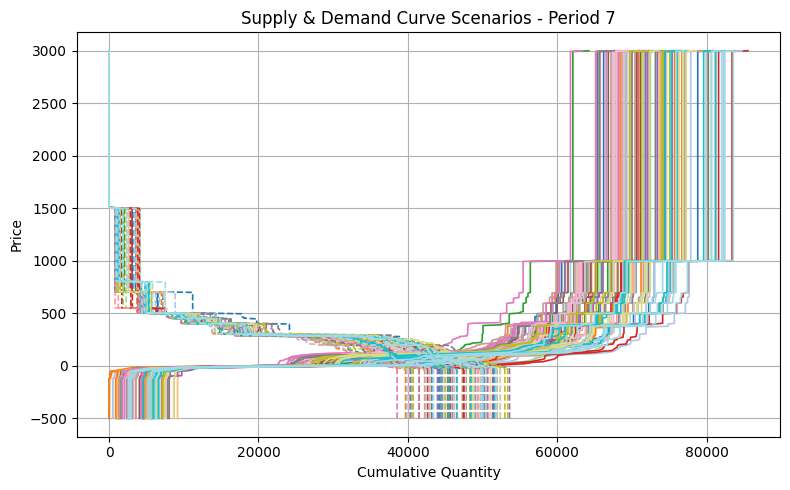

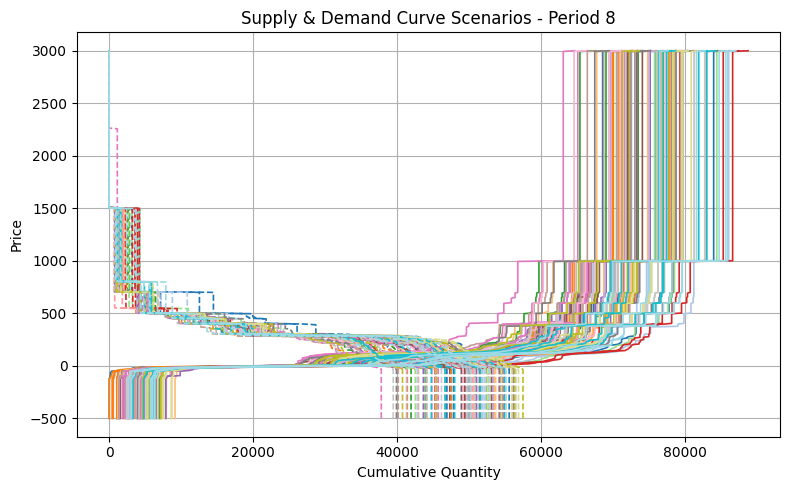

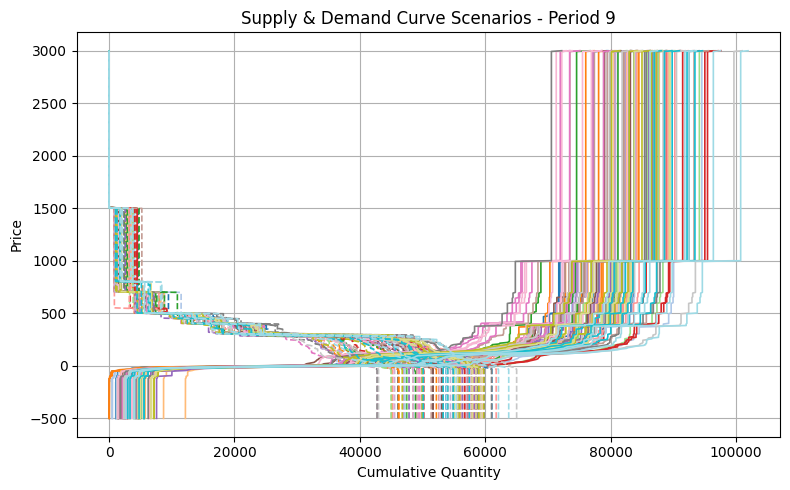

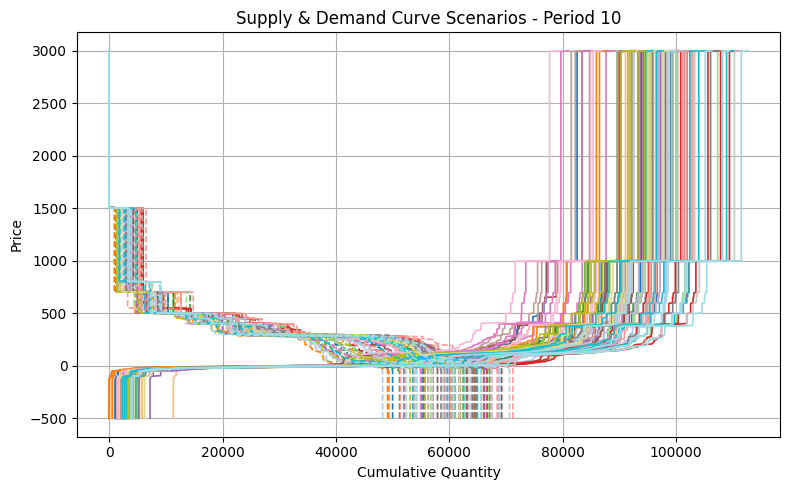

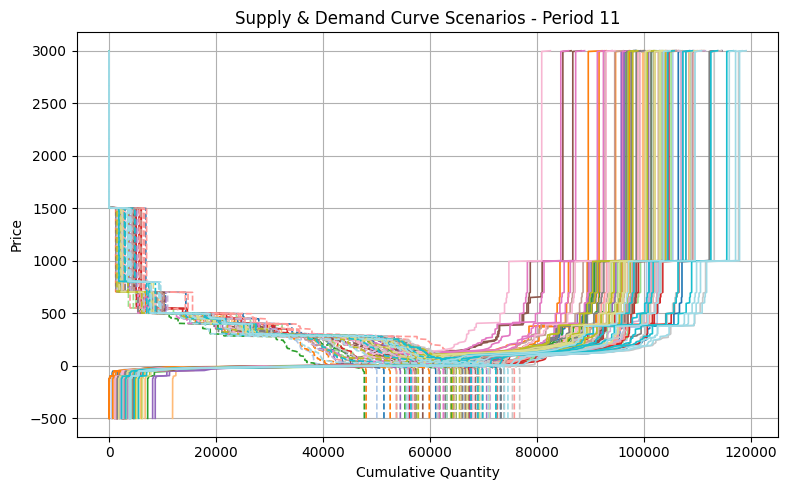

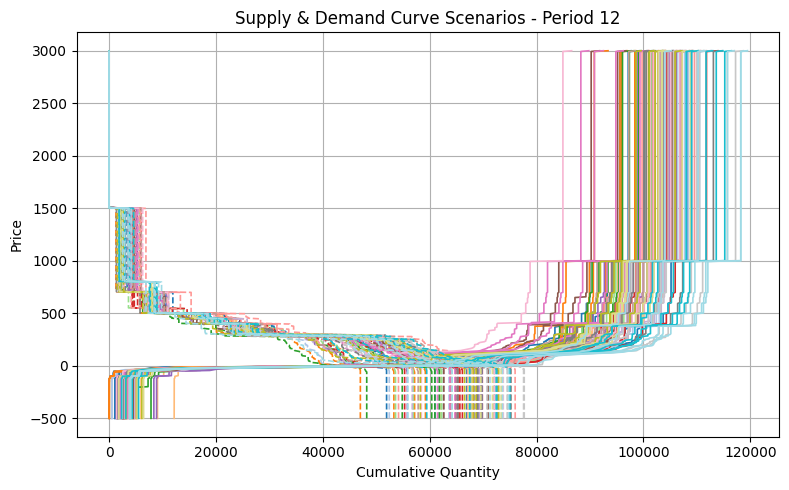

KeyboardInterrupt: 

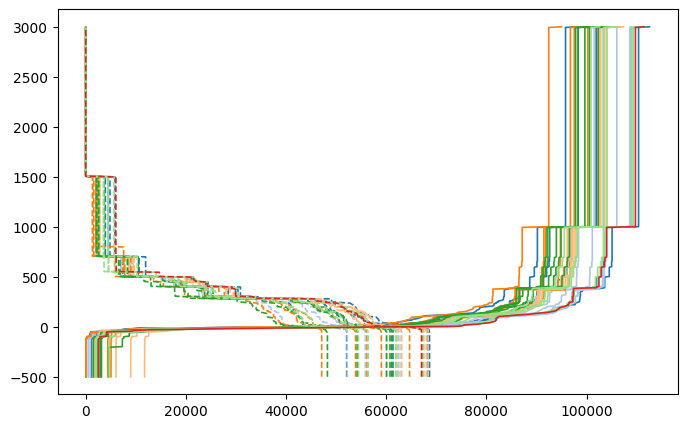

In [219]:
# --------------------------
# 날짜 범위 설정 (2025-04-20 ~ 2025-07-28)
# --------------------------
start_date = datetime(2025, 4, 20)
end_date   = datetime(2025, 7, 28)
# start_date = datetime(2025, 5, 1)
# end_date   = datetime(2025, 5, 5)
date_list  = pd.date_range(start=start_date, end=end_date, freq="D")

colors = plt.cm.tab20(np.linspace(0, 1, len(date_list)))  # 날짜별 색상 매핑

# --------------------------
# 데이터 저장된 폴더 경로
# --------------------------
data_dir = "rdcdata"   # 현재 경로 기준 ./rdcdata/

# --------------------------
# 각 Period(1~24) 마다 플롯
# --------------------------
for period in range(1, 25):
    plt.figure(figsize=(8, 5))
    any_plotted = False

    for date, color in zip(date_list, colors):
        date_str = date.strftime("%Y%m%d")
        fn       = os.path.join(data_dir, f"filteredcurve_{date_str}.csv")

        if not os.path.exists(fn):
            continue  # 파일 없으면 건너뛰기

        out = load_curves_from_path(fn, period)
        if out is None:
            continue

        price_grid, supply_vals, demand_vals = out
        plt.plot(supply_vals, price_grid, color=color, lw=1.2, label=f"{date_str} Supply")
        plt.plot(demand_vals, price_grid, color=color, lw=1.2, linestyle="--", label=f"{date_str} Demand")
        any_plotted = True

    if not any_plotted:
        print(f"{period}시: 데이터 없음")
        plt.close()
        continue

    plt.xlabel("Cumulative Quantity")
    plt.ylabel("Price")
    plt.title(f"Supply & Demand Curve Scenarios - Period {period}")

    # plt.title(f"Supply & Demand Curves with Market Uncertainty - Period {period}")
    plt.grid(True)
    # plt.legend(fontsize=6, loc="best", ncol=2)
    plt.tight_layout()
    plt.show()


Residual Demand Curve

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

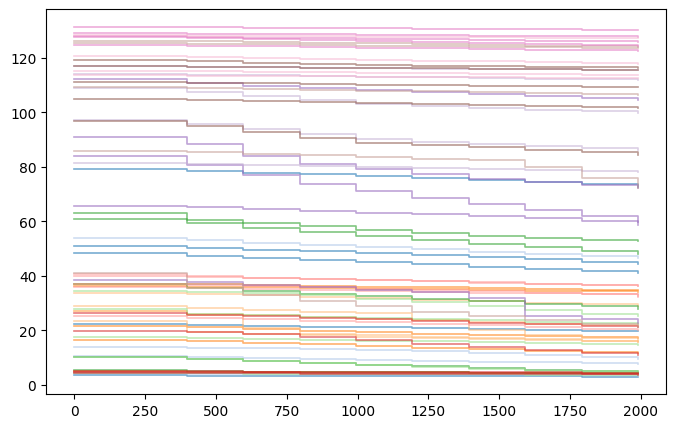

In [2]:
# --- RDC 계산 함수 ---
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0,p1 = price_grid[i], price_grid[i+1]
            r0,r1 = resid[i], resid[i+1]
            if r1 != r0:
                p_star = p0 - r0*(p1-p0)/(r1-r0)
                rdc.append((q, p_star))
    return rdc


# --- 날짜 범위 (2025-04-20 ~ 2025-07-28) ---
start_date = datetime(2025, 4, 20)
end_date   = datetime(2025, 7, 28)
date_list  = pd.date_range(start_date, end_date, freq="D")

wf_offer_grid = np.arange(0, 2000, 10)
B             = 10   # stepwise block 수
colors        = plt.cm.tab20(np.linspace(0,1,len(date_list)))  # 날짜별 색상 매핑

# stepwise 파라미터 저장용 dict
qini            = {}
qmax            = {}
lambda_da_block = {}
orig_cp         = {}

# --- 시간대별 Figure 하나씩 ---
for period in range(1, 25):

    plt.figure(figsize=(8,5))

    for date, color in zip(date_list, colors):
        date_str = date.strftime("%Y%m%d")
        scen_name = date_str
        fn        = os.path.join("rdcdata", f"filteredcurve_{date_str}.csv")

        if not os.path.exists(fn):
            print(f"파일 없음: {fn}")
            continue

        df = pd.read_csv(fn, encoding='utf-8-sig')

        sub = df[df['Time Period'] == period]
        sup = sub[sub['GC'] == 'V']
        dem = sub[sub['GC'] == 'C']
        if sup.empty or dem.empty:
            continue

        # 공급/수요 집계
        s_agg = sup.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
        s_agg['Cumul'] = s_agg['Amount'].cumsum()

        d_agg = dem.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
        d_agg['Cumul'] = d_agg['Amount'][::-1].cumsum()[::-1]

        # 보간
        s_f = interp1d(s_agg['Price'], s_agg['Cumul'],
                       kind='previous', bounds_error=False,
                       fill_value=(0, s_agg['Cumul'].iat[-1]))
        d_f = interp1d(d_agg['Price'], d_agg['Cumul'],
                       kind='previous', bounds_error=False,
                       fill_value=(d_agg['Cumul'].iat[0], 0))

        pg = np.linspace(min(s_agg['Price'].min(), d_agg['Price'].min()),
                         max(s_agg['Price'].max(), d_agg['Price'].max()), 500)
        sv = s_f(pg); dv = d_f(pg)

        # 교차점 (시장 균형가격)
        def resid0(p): return d_f(p) - s_f(p)
        try:
            sol0 = root_scalar(resid0, bracket=[pg[0], pg[-1]], method='bisect')
            orig_cp[(date_str, period)] = sol0.root if sol0.converged else np.nan
        except ValueError:
            orig_cp[(date_str, period)] = np.nan

        # RDC 계산
        rdc_pts = compute_rdc_by_sign_change(pg, dv, sv, wf_offer_grid)
        if not rdc_pts:
            continue
        qv, pv = zip(*rdc_pts)

        # stepwise 블록 경계
        q_breaks = np.linspace(min(qv), max(qv), B+1)

        for b in range(B):
            q_low, q_high = q_breaks[b], q_breaks[b+1]
            mask = (np.array(qv) >= q_low) & (np.array(qv) < q_high)
            if not mask.any():
                continue
            qini[(scen_name, period, b)] = q_low
            qmax[(scen_name, period, b)] = q_high - q_low
            lambda_da_block[(scen_name, period, b)] = np.mean(np.array(pv)[mask])

        # --- Stepwise 근사 곡선 플롯 ---
        q_step = [q_breaks[0]]
        p_step = [lambda_da_block.get((scen_name, period, 0), np.nan)]

        for b in range(B):
            if (scen_name, period, b) not in lambda_da_block:
                continue
            q_high = q_breaks[b+1]
            lam    = lambda_da_block[(scen_name, period, b)]
            q_step.extend([q_high])
            p_step.extend([lam])

        plt.step(q_step, p_step, where="post", lw=1.2, color=color, alpha=0.6)

    # 시간대별 제목
    hh1 = f"{period-1:02d}:00"; hh2 = f"{period%24:02d}:00"
    plt.title(f"Residual Demand Curve Scenarios - Period {period}")
    plt.legend()
    plt.xlabel("WF Offer Quantity (MW)")
    plt.ylabel("Price (€/MWh)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [3]:
# --- 1) DataFrame 만들기 ---
df = pd.DataFrame([
    {
        "scenario": scen,   # scen_name 대신 date_str (예: "20250720")
        "t": t,
        "b": b,
        "qini": qini[(scen,t,b)],
        "qmax": qmax[(scen,t,b)],
        "lam_da": lambda_da_block[(scen,t,b)]
    }
    for (scen,t,b) in qini.keys()
])

df = df.sort_values(["scenario","t","b"]).reset_index(drop=True)

# 저장
df.to_csv("rdc_scenarios0925.csv", index=False, encoding="utf-8-sig")
print("✅ rdc_scenarios0925.csv 저장 완료!")

NameError: name 'qini' is not defined

In [2]:
# --- 2) 불러오기 ---
df = pd.read_csv("rdc_scenarios0925.csv", encoding="utf-8-sig")  # 파일명 일반화

# 날짜 범위 필터 (2025-04-20 ~ 2025-07-28)
df["scenario"] = df["scenario"].astype(str)
df = df[(df["scenario"] >= "20250420") & (df["scenario"] <= "20250728")]

# 날짜별 scenario 리스트
date_range = sorted(df["scenario"].unique().tolist())   # ["20250420", ..., "20250728"]
S = list(range(len(date_range)))                        # 시나리오 index
T = list(range(1, 25))                                  # 시간
I = [0]
J = [1,2,3,4]
Δt = 0.25
rho = {s: 1/len(S) for s in S}                          # 균등 확률

# 시나리오 문자열(날짜) → 숫자 index 매핑
s_map = {date: idx for idx, date in enumerate(date_range)}

# --- 3) 최종 dict 구성 ---
qini_scen_final      = {}
qmax_scen_final      = {}
lambda_da_scen_final = {}
valid_blocks         = {t: [] for t in T}

for (s, t), sub in df.groupby(["scenario", "t"]):
    sub_sorted = sub.sort_values("qini").reset_index(drop=True)
    for b, r in sub_sorted.iterrows():
        s_idx = s_map[s]   # 예: "20250420" → 0, "20250421" → 1 ...
        qini_scen_final[(t,b,s_idx)]      = float(r["qini"])
        qmax_scen_final[(t,b,s_idx)]      = float(r["qmax"])
        lambda_da_scen_final[(t,b,s_idx)] = float(r["lam_da"])
        if r["qmax"] > 0:
            valid_blocks[t].append(b)

# 중복 제거
valid_blocks = {t: sorted(set(bs)) for t, bs in valid_blocks.items()}

print(f"총 시나리오 개수: {len(S)} (기간: {date_range[0]} ~ {date_range[-1]})")
print("예시 qini_scen_final keys:", list(qini_scen_final.keys())[:10])
print("예시 valid_blocks[1]:", valid_blocks[1])


총 시나리오 개수: 100 (기간: 20250420 ~ 20250728)
예시 qini_scen_final keys: [(1, 0, 0), (1, 1, 0), (1, 2, 0), (1, 3, 0), (1, 4, 0), (1, 5, 0), (1, 6, 0), (1, 7, 0), (1, 8, 0), (1, 9, 0)]
예시 valid_blocks[1]: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 18

실시간 가격

플롯된 파일 개수: 102


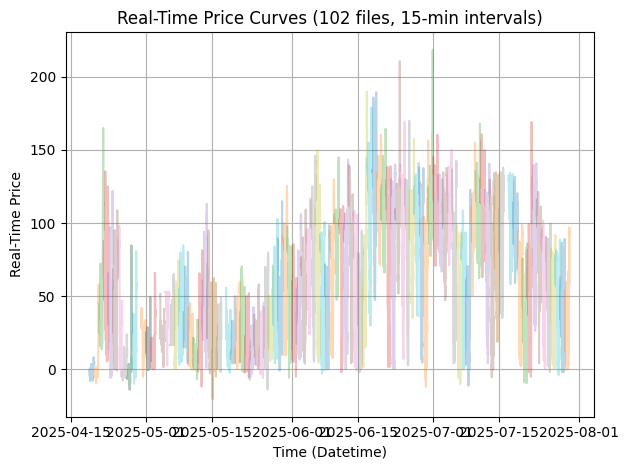

In [30]:
count = 0
for f in files:
    # 빈 파일은 스킵
    if os.path.getsize(f) == 0:
        print(f"⚠️ 빈 파일 건너뜀: {f}")
        continue

    try:
        df = pd.read_csv(f, sep=';', encoding='latin-1', skiprows=2, header=None)
    except Exception as e:
        print(f"⚠️ 읽기 실패: {f} ({e})")
        continue

    df = df.dropna(how="all", axis=1)
    if df.empty:
        continue

    df.columns = ["Year","Month","Day","Period","Price1","Price2"][:df.shape[1]]

    # 날짜 컬럼 정리
    for col in ["Year","Month","Day"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna(subset=["Year","Month","Day"])
    if df.empty:
        continue

    df["Year"]  = df["Year"].astype(int)
    df["Month"] = df["Month"].astype(int)
    df["Day"]   = df["Day"].astype(int)

    df["Date"] = pd.to_datetime(df[["Year","Month","Day"]])
    df["Datetime"] = df["Date"] + pd.to_timedelta((df["Period"]-1)*15, unit="m")

    if "Price1" in df.columns:
        plt.plot(df["Datetime"], df["Price1"], alpha=0.3)
        count += 1

print(f"플롯된 파일 개수: {count}")
plt.xlabel("Time (Datetime)")
plt.ylabel("Real-Time Price")
plt.title(f"Real-Time Price Curves ({count} files, 15-min intervals)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [31]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import os
# from glob import glob

# data_dir = "rtdata"

# # 🔹 2025-04-20 ~ 2025-07-28 파일만 선택
# files = sorted(glob(os.path.join(data_dir, "marginalpibc_2025*.1")))

# start_date = pd.to_datetime("2025-04-20")
# end_date   = pd.to_datetime("2025-07-28")

# all_data = []

# for f in files:
#     try:
#         df = pd.read_csv(f, sep=';', encoding='latin-1', skiprows=2, header=None)
#     except Exception:
#         continue

#     df = df.dropna(how="all", axis=1)
#     if df.empty:
#         continue

#     df.columns = ["Year","Month","Day","Period","Price1","Price2"][:df.shape[1]]

#     # 날짜 숫자 변환
#     for col in ["Year","Month","Day"]:
#         df[col] = pd.to_numeric(df[col], errors="coerce")
#     df = df.dropna(subset=["Year","Month","Day"])
#     if df.empty:
#         continue

#     df["Year"]  = df["Year"].astype(int)
#     df["Month"] = df["Month"].astype(int)
#     df["Day"]   = df["Day"].astype(int)

#     df["Date"] = pd.to_datetime(df[["Year","Month","Day"]])
#     df["Datetime"] = df["Date"] + pd.to_timedelta((df["Period"]-1)*15, unit="m")

#     # 기간 필터
#     df = df[(df["Date"] >= start_date) & (df["Date"] <= end_date)]

#     all_data.append(df[["Datetime","Price1"]])

# # 🔹 전체 기간 데이터 합치기
# if all_data:
#     full_df = pd.concat(all_data).sort_values("Datetime")
#     plt.figure(figsize=(14,6))
#     plt.plot(full_df["Datetime"], full_df["Price1"], lw=0.8)
#     plt.xlabel("Time (Datetime)")
#     plt.ylabel("Real-Time Price")
#     plt.title("Real-Time Price Curves (2025-04-20 ~ 2025-07-28, 15-min intervals)")
#     plt.grid(True)
#     plt.tight_layout()
#     plt.show()
# else:
#     print("⚠ 해당 기간에 데이터가 없습니다.")


전체 파일 개수: 102


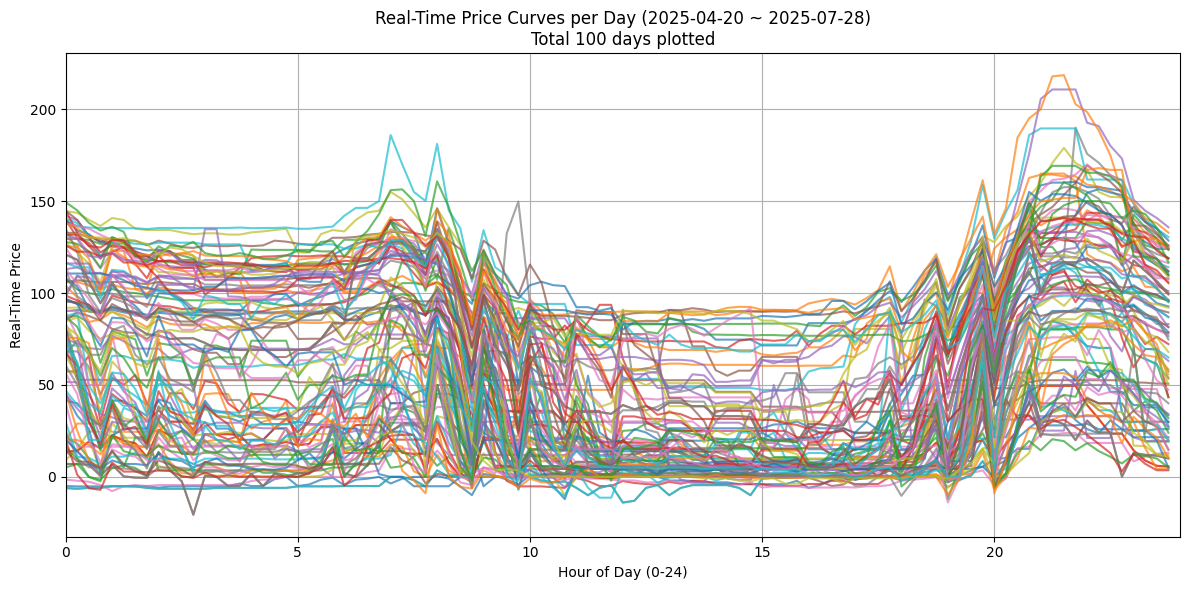

전체 파일 개수: 102
날짜 범위 내 파일 개수: 100
성공적으로 플롯된 날짜 개수: 100


In [50]:
data_dir = "rtdata"

# 🔹 전체 파일 리스트
files = sorted(glob(os.path.join(data_dir, "marginalpibc_2025*.1")))
print(f"전체 파일 개수: {len(files)}")

start_date = pd.to_datetime("2025-04-20")
end_date   = pd.to_datetime("2025-07-28")

plt.figure(figsize=(12,6))

count = 0
in_range_count = 0
for f in files:
    try:
        df = pd.read_csv(f, sep=';', encoding='latin-1', skiprows=1, header=None)
    except Exception:
        continue

    df = df.dropna(how="all", axis=1)
    if df.empty:
        continue

    df.columns = ["Year","Month","Day","Period","Price1","Price2"][:df.shape[1]]

    # 날짜 처리
    for col in ["Year","Month","Day"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna(subset=["Year","Month","Day"])
    if df.empty:
        continue

    df["Year"]  = df["Year"].astype(int)
    df["Month"] = df["Month"].astype(int)
    df["Day"]   = df["Day"].astype(int)

    df["Date"] = pd.to_datetime(df[["Year","Month","Day"]])

    # 날짜 범위 체크
    if not (start_date <= df["Date"].iloc[0] <= end_date):
        continue
    in_range_count += 1

    # x축: 하루 96개 구간 (0시~24시)
    x_vals = (df["Period"]-1) / 4
    plt.plot(x_vals, df["Price1"], alpha=0.7)
    count += 1

plt.xlabel("Hour of Day (0-24)")
plt.ylabel("Real-Time Price")
plt.title(f"Real-Time Price Curves per Day (2025-04-20 ~ 2025-07-28)\nTotal {count} days plotted")
plt.xlim(0, 24)
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"전체 파일 개수: {len(files)}")
print(f"날짜 범위 내 파일 개수: {in_range_count}")
print(f"성공적으로 플롯된 날짜 개수: {count}")

In [51]:
import pandas as pd
import os
from glob import glob

data_dir = "rtdata"
files = sorted(glob(os.path.join(data_dir, "marginalpibc_2025*.1")))

start_date = pd.to_datetime("2025-04-20")
end_date   = pd.to_datetime("2025-07-28")

day_counts = {}  # 날짜별 레코드 수 저장

for f in files:
    try:
        df = pd.read_csv(f, sep=";", encoding="latin-1", skiprows=1, header=None)
    except Exception:
        continue

    df = df.dropna(how="all", axis=1)
    if df.empty:
        continue

    df.columns = ["Year","Month","Day","Period","Price1","Price2"][:df.shape[1]]

    # 날짜 처리
    for col in ["Year","Month","Day"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna(subset=["Year","Month","Day"])
    if df.empty:
        continue

    df["Year"]  = df["Year"].astype(int)
    df["Month"] = df["Month"].astype(int)
    df["Day"]   = df["Day"].astype(int)
    df["Date"]  = pd.to_datetime(df[["Year","Month","Day"]])

    # 날짜 필터
    date_val = df["Date"].iloc[0]
    if not (start_date <= date_val <= end_date):
        continue

    # 해당 날짜의 데이터 개수 기록
    day_counts[str(date_val.date())] = len(df)

# 🔹 결과 출력
for d, n in sorted(day_counts.items()):
    status = "✅ OK" if n == 96 else f"⚠ {n}개"
    print(f"{d}: {status}")

print(f"\n총 {len(day_counts)}일 확인 완료")
print(f"96개 완전한 날 수: {sum(1 for v in day_counts.values() if v == 96)}")
print(f"불완전한 날 수: {sum(1 for v in day_counts.values() if v != 96)}")


2025-04-20: ✅ OK
2025-04-21: ✅ OK
2025-04-22: ✅ OK
2025-04-23: ✅ OK
2025-04-24: ✅ OK
2025-04-25: ✅ OK
2025-04-26: ✅ OK
2025-04-27: ✅ OK
2025-04-28: ✅ OK
2025-04-30: ✅ OK
2025-05-01: ✅ OK
2025-05-02: ✅ OK
2025-05-04: ✅ OK
2025-05-05: ✅ OK
2025-05-06: ✅ OK
2025-05-07: ✅ OK
2025-05-08: ✅ OK
2025-05-09: ✅ OK
2025-05-10: ✅ OK
2025-05-11: ✅ OK
2025-05-12: ✅ OK
2025-05-13: ✅ OK
2025-05-14: ✅ OK
2025-05-15: ✅ OK
2025-05-16: ✅ OK
2025-05-18: ✅ OK
2025-05-19: ✅ OK
2025-05-20: ✅ OK
2025-05-21: ✅ OK
2025-05-22: ✅ OK
2025-05-23: ✅ OK
2025-05-24: ✅ OK
2025-05-25: ✅ OK
2025-05-26: ✅ OK
2025-05-27: ✅ OK
2025-05-28: ✅ OK
2025-05-29: ✅ OK
2025-05-30: ✅ OK
2025-05-31: ✅ OK
2025-06-01: ✅ OK
2025-06-02: ✅ OK
2025-06-03: ✅ OK
2025-06-04: ✅ OK
2025-06-05: ✅ OK
2025-06-06: ✅ OK
2025-06-07: ✅ OK
2025-06-08: ✅ OK
2025-06-09: ✅ OK
2025-06-10: ✅ OK
2025-06-11: ✅ OK
2025-06-12: ✅ OK
2025-06-13: ✅ OK
2025-06-14: ✅ OK
2025-06-15: ✅ OK
2025-06-16: ✅ OK
2025-06-17: ✅ OK
2025-06-18: ✅ OK
2025-06-19: ✅ OK
2025-06-20: ✅ 

실시간 발전량

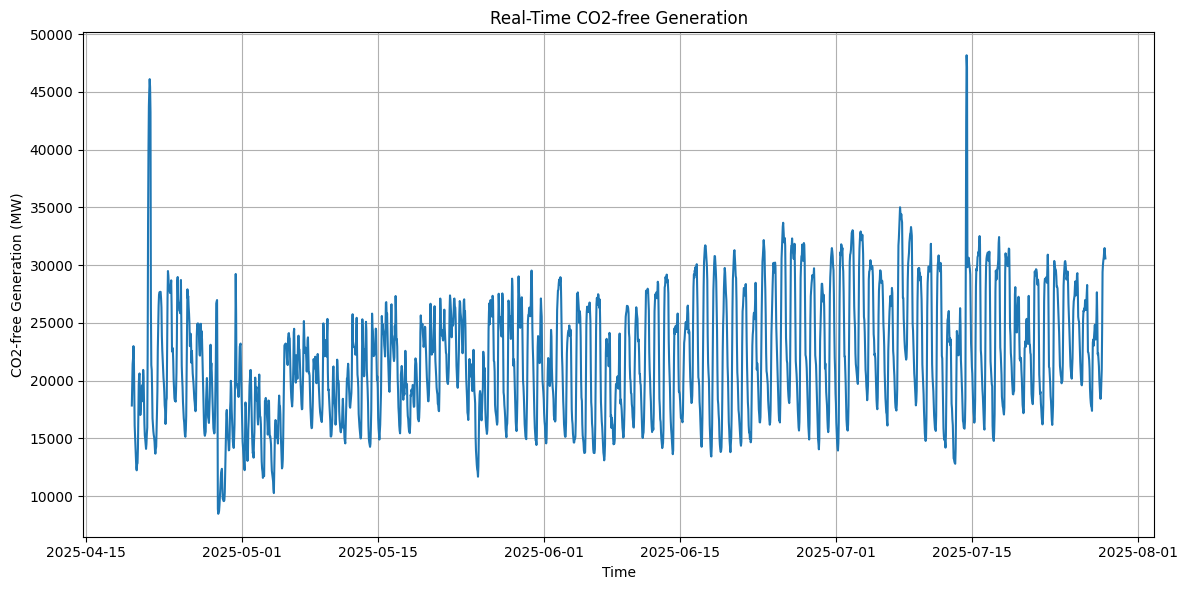

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "co2freegeneration.csv"  # 파일 경로로 교체

# CSV 읽기 (세미콜론 구분)
df = pd.read_csv(file_path, sep=';')

# datetime 변환
df['datetime'] = pd.to_datetime(df['datetime'])

# 플롯
plt.figure(figsize=(12,6))
plt.plot(df['datetime'], df['value'], lw=1.5)

plt.xlabel("Time")
plt.ylabel("CO2-free Generation (MW)")
plt.title("Real-Time CO2-free Generation")
plt.grid(True)
plt.tight_layout()
plt.show()


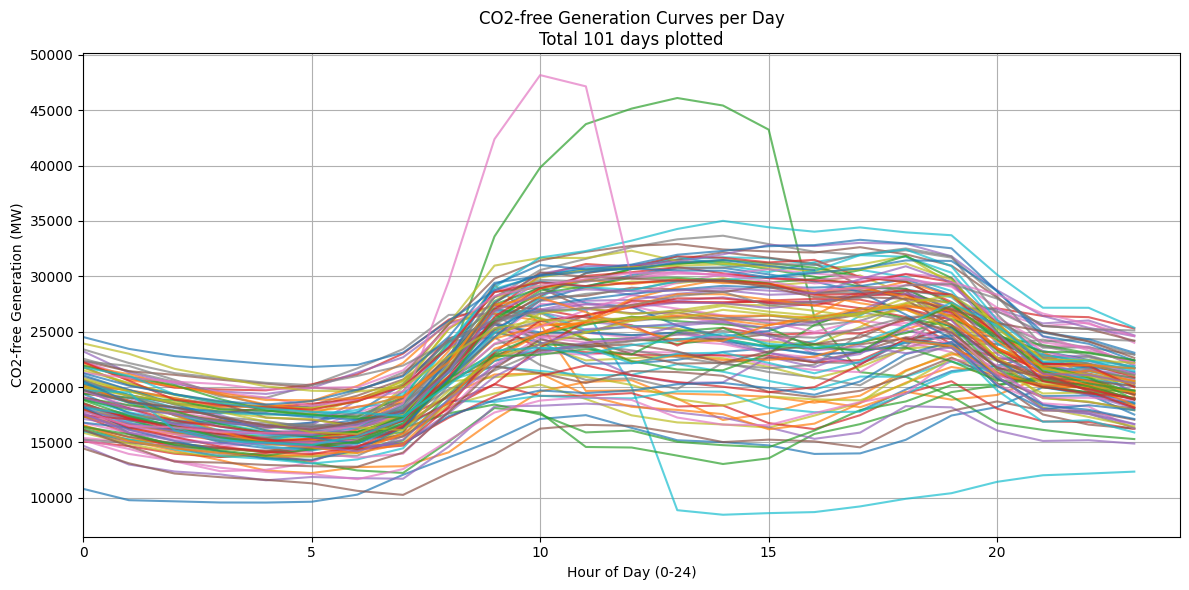

총 101일 데이터가 성공적으로 플롯되었습니다.


In [37]:
file_path = "co2freegeneration.csv"  # 파일 경로로 교체

# CSV 읽기
df = pd.read_csv(file_path, sep=";")

# datetime 변환
df["datetime"] = pd.to_datetime(df["datetime"])

# 날짜 컬럼 추가
df["date"] = df["datetime"].dt.date
df["hour"] = df["datetime"].dt.hour + df["datetime"].dt.minute/60.0

plt.figure(figsize=(12,6))

count = 0
for date, g in df.groupby("date"):
    plt.plot(g["hour"], g["value"], label=str(date), alpha=0.7)
    count += 1

plt.xlabel("Hour of Day (0-24)")
plt.ylabel("CO2-free Generation (MW)")
plt.title(f"CO2-free Generation Curves per Day\nTotal {count} days plotted")
plt.xlim(0, 24)
plt.grid(True)
# plt.legend(fontsize=6, loc="best")  # 필요시 날짜별 범례 표시
plt.tight_layout()
plt.show()

print(f"총 {count}일 데이터가 성공적으로 플롯되었습니다.")


In [62]:
# file_path = "co2freegeneration.csv"  # 파일 경로
# df = pd.read_csv(file_path, sep=";")

# # datetime 변환
# df["datetime"] = pd.to_datetime(df["datetime"])

# # 날짜/시간 컬럼 추가
# df["date"] = df["datetime"].dt.date
# df["hour"] = df["datetime"].dt.hour + df["datetime"].dt.minute/60.0

# plt.figure(figsize=(12,6))

# count = 0
# day_counts = {}
# for date, g in df.groupby("date"):
#     plt.plot(g["hour"], g["value"], label=str(date), alpha=0.7)
#     day_counts[str(date)] = len(g)
#     count += 1

# plt.xlabel("Hour of Day (0-24)")
# plt.ylabel("CO2-free Generation (MW)")
# plt.title(f"CO2-free Generation Curves per Day\nTotal {count} days plotted")
# plt.xlim(0, 24)
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # 🔹 날짜별 데이터 개수 확인
# for d, n in sorted(day_counts.items()):
#     status = "✅ OK" if n == 24 else f"⚠ {n}개"
#     print(f"{d}: {status}")

# print(f"\n총 {count}일 확인 완료")
# print(f"24개 완전한 날 수: {sum(1 for v in day_counts.values() if v == 24)}")
# print(f"불완전한 날 수: {sum(1 for v in day_counts.values() if v != 24)}")


In [63]:
# bad_dates = [d for d, n in day_counts.items() if n != 24]

# for bad in bad_dates:
#     g = df[df["date"] == pd.to_datetime(bad)].copy()
#     hours_present = sorted(g["datetime"].dt.hour.unique())
#     print(f"\n날짜: {bad}")
#     print("존재하는 시간:", hours_present)
#     print("누락된 시간:", set(range(24)) - set(hours_present))


In [64]:
# import pandas as pd

# file_path = "co2freegeneration.csv"
# df = pd.read_csv(file_path, sep=";")
# df["datetime"] = pd.to_datetime(df["datetime"])
# df["date"] = df["datetime"].dt.date
# df["hour"] = df["datetime"].dt.hour

# # 날짜별 24시간 채워 넣기
# filled_list = []
# for date, g in df.groupby("date"):
#     # 해당 날짜의 모든 시간 (0~23)
#     full_hours = pd.DataFrame({"hour": range(24)})
#     full_hours["date"] = pd.to_datetime(str(date))
    
#     # 실제 데이터 merge
#     # 실제 데이터 준비
#     g_day = g[["date", "hour", "value"]].copy()
#     g_day["date"] = pd.to_datetime(g_day["date"])   # ✅ 타입 통일

#     # merge 수행
#     merged = pd.merge(full_hours, g_day, on=["date","hour"], how="left")
    
#     # datetime 다시 생성
#     merged["datetime"] = merged["date"] + pd.to_timedelta(merged["hour"], unit="h")
#     filled_list.append(merged)

# # 모든 날짜 합치기
# df_filled = pd.concat(filled_list, ignore_index=True)

# print("보강 전:", len(df), "행")
# print("보강 후:", len(df_filled), "행 (날짜 × 24)")

# # 🔹 선형 보간
# df_filled["value"] = df_filled["value"].interpolate()

# # CSV로 저장
# df_filled.to_csv("co2freegeneration_filled.csv", index=False, encoding="utf-8-sig")
# print("보강된 데이터를 'co2freegeneration_filled.csv'로 저장했습니다.")


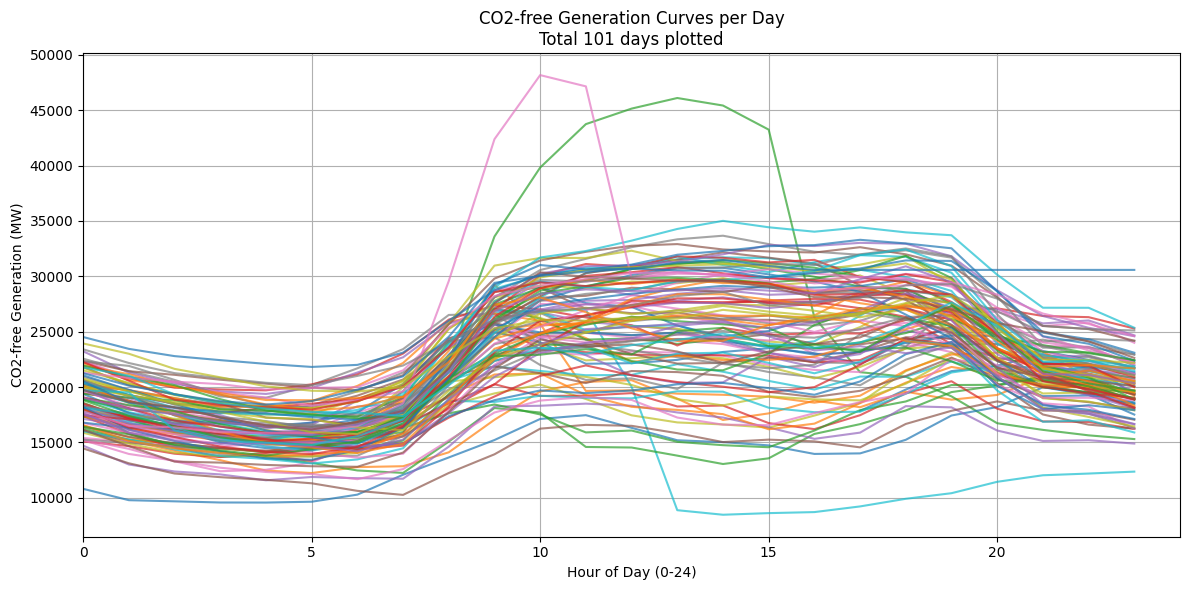

2025-04-19: ✅ OK
2025-04-20: ✅ OK
2025-04-21: ✅ OK
2025-04-22: ✅ OK
2025-04-23: ✅ OK
2025-04-24: ✅ OK
2025-04-25: ✅ OK
2025-04-26: ✅ OK
2025-04-27: ✅ OK
2025-04-28: ✅ OK
2025-04-29: ✅ OK
2025-04-30: ✅ OK
2025-05-01: ✅ OK
2025-05-02: ✅ OK
2025-05-03: ✅ OK
2025-05-04: ✅ OK
2025-05-05: ✅ OK
2025-05-06: ✅ OK
2025-05-07: ✅ OK
2025-05-08: ✅ OK
2025-05-09: ✅ OK
2025-05-10: ✅ OK
2025-05-11: ✅ OK
2025-05-12: ✅ OK
2025-05-13: ✅ OK
2025-05-14: ✅ OK
2025-05-15: ✅ OK
2025-05-16: ✅ OK
2025-05-17: ✅ OK
2025-05-18: ✅ OK
2025-05-19: ✅ OK
2025-05-20: ✅ OK
2025-05-21: ✅ OK
2025-05-22: ✅ OK
2025-05-23: ✅ OK
2025-05-24: ✅ OK
2025-05-25: ✅ OK
2025-05-26: ✅ OK
2025-05-27: ✅ OK
2025-05-28: ✅ OK
2025-05-29: ✅ OK
2025-05-30: ✅ OK
2025-05-31: ✅ OK
2025-06-01: ✅ OK
2025-06-02: ✅ OK
2025-06-03: ✅ OK
2025-06-04: ✅ OK
2025-06-05: ✅ OK
2025-06-06: ✅ OK
2025-06-07: ✅ OK
2025-06-08: ✅ OK
2025-06-09: ✅ OK
2025-06-10: ✅ OK
2025-06-11: ✅ OK
2025-06-12: ✅ OK
2025-06-13: ✅ OK
2025-06-14: ✅ OK
2025-06-15: ✅ OK
2025-06-16: ✅ 

In [60]:
file_path = "co2freegeneration_filled.csv"
df = pd.read_csv(file_path, sep=",")   # ✅ 쉼표 구분자로 읽기

# datetime 변환
df["datetime"] = pd.to_datetime(df["datetime"])


# 날짜/시간 컬럼 추가
df["date"] = df["datetime"].dt.date
df["hour"] = df["datetime"].dt.hour + df["datetime"].dt.minute/60.0

plt.figure(figsize=(12,6))

count = 0
day_counts = {}
for date, g in df.groupby("date"):
    plt.plot(g["hour"], g["value"], label=str(date), alpha=0.7)
    day_counts[str(date)] = len(g)
    count += 1

plt.xlabel("Hour of Day (0-24)")
plt.ylabel("CO2-free Generation (MW)")
plt.title(f"CO2-free Generation Curves per Day\nTotal {count} days plotted")
plt.xlim(0, 24)
plt.grid(True)
plt.tight_layout()
plt.show()

# 🔹 날짜별 데이터 개수 확인
for d, n in sorted(day_counts.items()):
    status = "✅ OK" if n == 24 else f"⚠ {n}개"
    print(f"{d}: {status}")

print(f"\n총 {count}일 확인 완료")
print(f"24개 완전한 날 수: {sum(1 for v in day_counts.values() if v == 24)}")
print(f"불완전한 날 수: {sum(1 for v in day_counts.values() if v != 24)}")


In [61]:
bad_dates = [d for d, n in day_counts.items() if n != 24]

for bad in bad_dates:
    g = df[df["date"] == pd.to_datetime(bad)].copy()
    hours_present = sorted(g["datetime"].dt.hour.unique())
    print(f"\n날짜: {bad}")
    print("존재하는 시간:", hours_present)
    print("누락된 시간:", set(range(24)) - set(hours_present))


## 시나리오 생성

In [ ]:
# # 15분 분할
# #7월 20일 기준
# rt_price_15min = [
#     75.78, 75.54, 72.72, 42.23, 75.30, 75.30, 61.91, 35.25, 75.30, 48.33,
#     39.81, 23.08, 65.80, 49.92, 33.81, 18.07, 45.68, 35.81, 26.04, 30.98,
#     32.11, 36.47, 34.14, 29.49, 27.58, 34.34, 21.44, 33.44, 26.00,  3.30,
#     -1.99, -8.99, 28.79,  0.49, -5.51, -6.31,  3.52,  0.65, -1.01, -5.90,
#     -0.97, -3.00, -3.00,  0.00,  0.01,  4.31,  0.00,  0.00,  0.99,  0.99,
#      0.14,  0.00,  0.65,  0.65,  0.65,  0.00,  0.99,  0.00,  0.00,  0.00,
#     -0.65, -0.65, -0.50, -0.65,  0.00,  0.00,  0.00, -0.01, -0.61,  0.00,
#      0.00,  0.00,  0.00,  0.00,  0.00,  0.00, -9.70, -0.97, 20.33, 79.89,
#     -8.99,  8.81, 49.88, 83.87, 36.84, 66.60, 72.19, 75.54, 82.80, 82.80,
#     85.21, 82.01, 86.16, 78.72, 72.27, 53.31
# ]
# rt_price_15min = 0.4 * np.array(rt_price_15min)  # 15분 단위 RT 가격
# # 1) 15분 가격을 (24시간 × 4구간) 배열로 재형성
# rt15_arr = np.array(rt_price_15min).reshape(24, 4)

# # (t,j) → price 사전 생성
# #  t=1..24,  j=1..4
# lambda_rt = {
#     (t, j): float(rt15_arr[t-1, j-1])
#     for t in T for j in J
# }
# sigma_eta = 0.1  # 실시간 가격 변동성 (5%)
# # λ_rt_act[(t,j,s)] : 시나리오 s의 시간 t, 구간 j 실시간 가격
# lambda_rt_act = {
#     (t, j, s): rt15_arr[t-1, j-1] * (1 + sigma_eta * np.random.randn())
#     for t in T for j in J for s in S
# }

In [3]:
import glob

In [4]:
# ---------------------------
# 1) 파일 로드
# ---------------------------
# 발전량 (결측 보정된 버전)
df_pwf = pd.read_csv("co2freegeneration_filled.csv", sep=",")
df_pwf["datetime"] = pd.to_datetime(df_pwf["datetime"])
df_pwf["date"] = df_pwf["datetime"].dt.date
df_pwf["hour"] = df_pwf["datetime"].dt.hour

# 실시간 가격 (marginalpibc에서)
rt_files = sorted(glob.glob("rtdata/marginalpibc_2025*.1"))

# ---------------------------
# 1) 기본 설정
# ---------------------------
start_date = pd.to_datetime("2025-04-20")
end_date   = pd.to_datetime("2025-07-28")
dates = pd.date_range(start=start_date, end=end_date, freq="D")

W = list(range(len(dates)))   # 0..99
rho_w = {w: 1/len(W) for w in W}

# ---------------------------
# 2) 빅 딕셔너리 초기화
# ---------------------------
qini_big, qmax_big, lambda_da_big = {}, {}, {}
pwf_big, rt_big = {}, {}
valid_blocks_by_w = defaultdict(list)

# rtdata 파일 목록
# ---------------------------
# 3) 날짜별 시나리오 생성
# ---------------------------
for w, date in enumerate(dates):
    date_str = date.strftime("%Y%m%d")

    # --- RDC 매핑 (날짜 = 시나리오) ---
    for (t,b,s) in qini_scen_final.keys():
        if s != w:   # 🔹 시나리오 인덱스로 매칭
            continue
        qini_big[(t,b,w)]      = qini_scen_final[(t,b,s)]
        qmax_big[(t,b,w)]      = qmax_scen_final[(t,b,s)]
        lambda_da_big[(t,b,w)] = lambda_da_scen_final[(t,b,s)]
        if qmax_big[(t,b,w)] > 0:
            valid_blocks_by_w[(t,w)].append(b)

    # --- 발전량 (pwf, 시간 단위) ---
    sub_pwf = df_pwf[df_pwf["date"] == date.date()]
    for _, row in sub_pwf.iterrows():
        t = int(row["hour"]) + 1   # 0~23 → 1~24
        pwf_big[(0,t,w)] = row["value"]/20

    # --- 실시간 가격 (rt, 15분 단위 96개 → t,j로 매핑) ---
    fmatch = [f for f in rt_files if date_str in f]
    if fmatch:
        df_rt = pd.read_csv(fmatch[0], sep=";", encoding="latin-1", skiprows=1, header=None)
        df_rt = df_rt.dropna(how="all", axis=1)
        df_rt.columns = ["Year","Month","Day","Period","Price1","Price2"][:df_rt.shape[1]]

        df_rt = df_rt.dropna(subset=["Period","Price1"])
        df_rt["Period"] = df_rt["Period"].astype(int)

        # 🔹 Period가 반드시 1~96까지 있어야 함 (누락 방지)
        if set(df_rt["Period"].unique()) == set(range(1,97)):
            for _, row in df_rt.iterrows():
                period = int(row["Period"])
                t = (period-1)//4 + 1   # 1~96 → 1~24
                j = (period-1)%4 + 1    # 1~96 → 1~4
                rt_big[(t,j,w)] = float(row["Price1"])/4
        else:
            print(f"⚠ {date.date()} RT 데이터 개수 부족: {len(df_rt)}개")


    # 블록 정리
    for t in range(1,25):
        valid_blocks_by_w[(t,w)] = sorted(set(valid_blocks_by_w[(t,w)]))

# ---------------------------
# 4) 결과 확인
# ---------------------------
print("총 시나리오 수:", len(W))        # 100
print("예시 qini_big:", list(qini_big.items())[:3])
print("예시 pwf_big:", list(pwf_big.items())[:3])
print("예시 rt_big:", list(rt_big.items())[:6])  # j=1..4 구조 확인


총 시나리오 수: 100
예시 qini_big: [((1, 0, 0), 0.0), ((1, 1, 0), 7.96), ((1, 2, 0), 19.9)]
예시 pwf_big: [((0, 1, 0), 804.725), ((0, 2, 0), 758.316666666667), ((0, 3, 0), 711.741666666667)]
예시 rt_big: [((1, 1, 0), -1.25), ((1, 2, 0), -1.3025), ((1, 3, 0), -1.3025), ((1, 4, 0), -1.3025), ((2, 1, 0), -1.3025), ((2, 2, 0), -1.3025)]


In [121]:
# ---------------------------
# 5) 특정 날짜(2025-07-20) 디버그 출력
# ---------------------------
check_date = "20250720"
w_check = None
for w, date in enumerate(dates):
    if date.strftime("%Y%m%d") == check_date:
        w_check = w
        break

if w_check is not None:
    print(f"\n✅ 시나리오 w={w_check} (날짜={check_date}) 확인")
    
    # 발전량 확인
    print("\n--- 발전량 pwf_big ---")
    for t in range(1, 25):
        print(f"t={t}: {pwf_big.get((0,t,w_check), '없음')}")

    # 실시간 가격 확인
    print("\n--- 실시간 가격 rt_big (t=1..3만 예시) ---")
    for t in range(1, 4):   # 앞 3시간만 예시 출력
        for j in range(1, 5):
            print(f"t={t}, j={j}: {rt_big.get((t,j,w_check), '없음')}")

    # RDC 확인
    print("\n--- RDC lambda_da_big (t=1 일부) ---")
    for b in valid_blocks_by_w[(1, w_check)][:5]:  # 앞 5개 블록만
        print(f"t=1, b={b}: {lambda_da_big.get((1,b,w_check), '없음')}")



✅ 시나리오 w=91 (날짜=20250720) 확인

--- 발전량 pwf_big ---
t=1: 1097.4833333333336
t=2: 1045.375
t=3: 1008.3291666666664
t=4: 945.0666666666664
t=5: 894.5333333333335
t=6: 875.5583333333336
t=7: 858.8333333333336
t=8: 866.9833333333336
t=9: 1019.725
t=10: 1139.6416666666664
t=11: 1145.7208333333335
t=12: 1170.5125
t=13: 1146.675
t=14: 1252.3166666666664
t=15: 1267.15
t=16: 1185.4958333333336
t=17: 1192.0666666666664
t=18: 1159.0458333333336
t=19: 1278.0875
t=20: 1366.6208333333336
t=21: 1229.9875
t=22: 1158.4458333333337
t=23: 1156.1333333333337
t=24: 1120.8791666666664

--- 실시간 가격 rt_big (t=1..3만 예시) ---
t=1, j=1: 18.945
t=1, j=2: 18.885
t=1, j=3: 18.18
t=1, j=4: 10.5575
t=2, j=1: 18.825
t=2, j=2: 18.825
t=2, j=3: 15.4775
t=2, j=4: 8.8125
t=3, j=1: 18.825
t=3, j=2: 12.0825
t=3, j=3: 9.9525
t=3, j=4: 5.77

--- RDC lambda_da_big (t=1 일부) ---
t=1, b=0: 73.96843962866794
t=1, b=1: 73.87660893927134
t=1, b=2: 73.78477824987473
t=1, b=3: 73.69294756047813
t=1, b=4: 73.60111687108154


In [122]:
print(list(qini_scen_final.keys())[:10])


[(1, 0, 0), (1, 1, 0), (1, 2, 0), (1, 3, 0), (1, 4, 0), (1, 5, 0), (1, 6, 0), (1, 7, 0), (1, 8, 0), (1, 9, 0)]


## 최적화 모델

In [8]:
blocks = valid_blocks_by_w.get((t,w), valid_blocks[t])


In [9]:
eta_c, eta_d    = 0.9, 0.9
E0, E_min, E_max = 1400, 500, 2250
pc_max, pd_max  = 500, 500
Δt = 0.25

In [ ]:
# W = list(range(50))   # 0..99
# rho_w = {w: 1/len(W) for w in W}


In [10]:
model = gp.Model("WF_ESS_3D_RDC_RT_WF")

# ---------- 1단계(H&N) ----------
u = model.addVars([(t,b) for t in T for b in valid_blocks[t]],
                  vtype=GRB.BINARY, name="u")

# qvar, p_bid도 w에 종속(DA 기대값을 w로 평균)
qvar  = model.addVars([(t,b) for t in T for b in valid_blocks[t]],
                      lb=0.0, name="qvar")
p_bid = model.addVars(T, lb=0.0, name="p_bid")

# ESS on/off (H&N)
u_c = model.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_c")
u_d = model.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_d")

# ---------- 2단계(Recourse; w별) ----------
p_c = model.addVars([(t,j,w) for t in T for j in J for w in W],
                    lb=0.0, ub=pc_max, name="p_c")
p_d = model.addVars([(t,j,w) for t in T for j in J for w in W],
                    lb=0.0, ub=pd_max, name="p_d")
E_q = model.addVars([(t,j,w) for t in T for j in J for w in W],
                    lb=E_min, ub=E_max, name="E_q")
p_b = model.addVars([(t,j,w) for t in T for j in J for w in W],
                    lb=0.0, name="p_b")

# LDR 계수(공통)
p_hat_c = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_c")
p_hat_d = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_d")
D_c     = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_c")
D_d     = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_d")

# ---------- 목적함수 ----------
# DA 수익
# DA_rev = gp.quicksum(
#     rho_w[w] * gp.quicksum(
#         lambda_da_big[(t,b,w)] * (u[t,b] * qini_big[(t,b,w)] + qvar[t,b])
#         for b in valid_blocks_by_w.get((t,w), [])
#         if (t,b,w) in lambda_da_big
#     )
#     for w in W for t in T
# )


# # RT 수익
# RT_rev = gp.quicksum(
#     rho_w[w] * gp.quicksum(
#         rt_big[(t,j,w)] * (p_b[t,j,w] - p_bid[t]/4.0)
#         for j in J if (t,j,w) in rt_big
#     )
#     for w in W for t in T
# )
# 목적함수 = DA + RT
DA_rev = gp.quicksum(
    rho_w[w] * gp.quicksum(
        lambda_da_big[(t,b,w)] * (u[t,b] * qini_big[(t,b,w)] + qvar[t,b])
        for b in valid_blocks_by_w.get((t,w), [])
        if (t,b,w) in lambda_da_big
    )
    for w in W for t in T
)

RT_rev = gp.quicksum(
    rho_w[w] * gp.quicksum(
        rt_big[(t,j,w)] * (p_b[t,j,w] - p_bid[t]/4.0)
        for j in J if (t,j,w) in rt_big
    )
    for w in W for t in T
)

model.setObjective(DA_rev + RT_rev, GRB.MAXIMIZE)
model.setObjective(DA_rev + RT_rev, GRB.MAXIMIZE)

Set parameter Username
Set parameter LicenseID to value 2665974
Academic license - for non-commercial use only - expires 2026-05-14


In [11]:
# ---------- 제약식 (통일 버전) ----------
# 모든 (t,j,w)에 대해 균형
for w in W:
    for t in T:
        for j in J:
            model.addConstr(
                p_b[(t,j,w)] ==
                (gp.quicksum(pwf_big[(i,t,w)] for i in I)/4.0)   # 15분 평균 풍력
                + p_d[(t,j,w)] - p_c[(t,j,w)]                    # ESS 순발전
                - p_bid[t]/4.0,                                  # DA 약속의 1/4
                name=f"rt_balance_{t}_{j}_w{w}"
            )
# (6c) 매 시각 블록 하나 선택 (1단계 공통)
for t in T:
    model.addConstr(gp.quicksum(u[t,b] for b in valid_blocks[t]) == 1,
                    name=f"one_block_{t}")

# # (6d) qvar ≤ qmax * u  (모든 w에서 성립 → qmax_big[(t,b,w)] 사용, qvar은 w-비의존)
# for w in W:
#     for t in T:
#         for b in valid_blocks[t]:
#             model.addConstr(
#                 qvar[t,b] <= qmax_big[(t,b,w)] * u[t,b],
#                 name=f"qvar_max_{t}_{b}_w{w}"
#             )
for w in W:
    for t in T:
        for b in valid_blocks_by_w.get((t,w), []):
            model.addConstr(
                qvar[t,b] <= qmax_big[(t,b,w)] * u[t,b],
                name=f"qvar_max_{t}_{b}_w{w}"
            )

# (6e) p_bid 정의 (1단계 공통결정, 기대값 기반)
#  E[qini] = Σ_w rho_w[w] * qini_big[(t,b,w)]
# mu_qini = {(t,b): sum(rho_w[w]*qini_big[(t,b,w)] for w in W)
#            for t in T for b in valid_blocks[t]}

# for t in T:
#     model.addConstr(
#         p_bid[t] == gp.quicksum(u[t,b]*mu_qini[(t,b)] + qvar[t,b]
#                                 for b in valid_blocks[t]),
#         name=f"p_bid_def_{t}"
#     )
# (6e) p_bid 정의 (qini는 시나리오와 무관 → 첫 시나리오 값 사용)
mu_qini = {
    (t,b): sum(rho_w[w] * qini_big[(t,b,w)] for w in W if (t,b,w) in qini_big)
    for t in T for b in valid_blocks[t]
}

for t in T:
    model.addConstr(
        p_bid[t] == gp.quicksum(u[t,b]*mu_qini[(t,b)] + qvar[t,b]
                                for b in valid_blocks[t]),
        name=f"p_bid_def_{t}"
    )
# (6h, 6i) LDR (2단계, w-의존)  —— delta_rt 대신 실시간가격 rt_big 사용
#     p_c = u_c * (p̂_c + D_c * λ_rt),   p_d = u_d * (p̂_d + D_d * λ_rt)
for w in W:
    for t in T:
        for j in J:
            model.addConstr(
                p_c[(t,j,w)] == u_c[(t,j)] * (p_hat_c[(t,j)] + D_c[(t,j)] * rt_big[(t,j,w)]),
                name=f"LDR_pc_{t}_{j}_w{w}"
            )
            model.addConstr(
                p_d[(t,j,w)] == u_d[(t,j)] * (p_hat_d[(t,j)] + D_d[(t,j)] * rt_big[(t,j,w)]),
                name=f"LDR_pd_{t}_{j}_w{w}"
            )

# (6k) 동시 충방전 금지 + Big-M
for t in T:
    for j in J:
        model.addConstr(u_c[(t,j)] + u_d[(t,j)] <= 1, name=f"no_simul_{t}_{j}")
        for w in W:
            model.addConstr(p_c[(t,j,w)] <= pc_max * u_c[(t,j)],
                            name=f"pc_bigm_{t}_{j}_w{w}")
            model.addConstr(p_d[(t,j,w)] <= pd_max * u_d[(t,j)],
                            name=f"pd_bigm_{t}_{j}_w{w}")

# (6j) SOC 전이 (2단계, w-의존)
for w in W:
    for t in T:
        for j in J:
            prev = (E0 if (t == 1 and j == 1)
                    else (E_q[(t-1,4,w)] if j == 1 else E_q[(t,j-1,w)]))
            model.addConstr(
                E_q[(t,j,w)] == prev + Δt*(eta_c*p_c[(t,j,w)] - p_d[(t,j,w)]/eta_d),
                name=f"SOC_{t}_{j}_w{w}"
            )

# (6g) DA vs RT 약속량 경계 (1단계 p_bid[t] vs 2단계 실현치)
#  풍력(gen) 시나리오 인덱스는 triplet_of[w][1] 이나,
#  이미 pwf_big[(i,t,w)] 로 매핑되어 있으니 그걸 그대로 사용
for w in W:
    for t in T:
        # 상한: 풍력 발전 + 방전
        rhs = 1000 + gp.quicksum(p_d[(t,j,w)] for j in J)
        # 하한: -충전
        model.addConstr(-gp.quicksum(p_c[(t,j,w)] for j in J) <= p_bid[t],
                        name=f"bid_low_{t}_w{w}")
        # 상한
        model.addConstr(p_bid[t] <= rhs, name=f"bid_up_sync_{t}_w{w}")

# 옵션 파라미터
model.Params.MIPGap = 0.00000002
# model.Params.TimeLimit = 3600
# model.Params.Heuristics = 0.1
# model.feasRelaxS(0, True, False, True)
model.optimize()
assert model.Status == GRB.OPTIMAL
Z_RP = model.ObjVal

Set parameter MIPGap to value 2e-08
Gurobi Optimizer version 10.0.2 build v10.0.2rc0 (win64)

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 520944 rows, 48552 columns and 1108820 nonzeros
Model fingerprint: 0x0cb4d5e4
Model has 19200 quadratic constraints
Variable types: 43584 continuous, 4968 integer (4968 binary)
Coefficient statistics:
  Matrix range     [2e-01, 2e+03]
  QMatrix range    [3e-03, 5e+01]
  QLMatrix range   [1e+00, 1e+00]
  Objective range  [3e-05, 1e+05]
  Bounds range     [1e+00, 2e+03]
  RHS range        [1e+00, 1e+03]
Presolve removed 480320 rows and 13955 columns
Presolve time: 1.66s
Presolved: 58522 rows, 35749 columns, 302344 nonzeros
Presolved model has 768 SOS constraint(s)
Variable types: 31206 continuous, 4543 integer (4539 binary)
Found heuristic solution: objective 440409.30112
Root relaxation presolved: 48590 rows, 25529

ev/eev 시도: 0929

In [ ]:
# RDC 시나리오 집합과 가중치(예: 50개 균등)
S_rdc = list(range(100))
rho_rdc = {s: 1/len(S_rdc) for s in S_rdc}

# μ_λ, μ_qini, μ_qmax 계산 (RDC만 평균)
mu_lambda_RDC = {
    (t,b): sum(rho_rdc[s] * lambda_da_scen_final[(t,b,s)] for s in S_rdc)
    for t in T for b in valid_blocks[t]
}
mu_qini_RDC = {
    (t,b): sum(rho_rdc[s] * qini_scen_final[(t,b,s)] for s in S_rdc)
    for t in T for b in valid_blocks[t]
}
mu_qmax_RDC = {
    (t,b): sum(rho_rdc[s] * qmax_scen_final[(t,b,s)] for s in S_rdc)
    for t in T for b in valid_blocks[t]
}


In [360]:
EV = gp.Model("EV_RDC_only")

# 1단계
u_e   = EV.addVars([(t,b) for t in T for b in valid_blocks[t]], vtype=GRB.BINARY, name="u")
qv_e  = EV.addVars([(t,b) for t in T for b in valid_blocks[t]], lb=0.0, name="qvar")
p_bid_e = EV.addVars(T, lb=0.0, name="p_bid")

u_c_e = EV.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_c")
u_d_e = EV.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_d")
p_hat_c_e = EV.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_c")
p_hat_d_e = EV.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_d")
D_c_e     = EV.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_c")
D_d_e     = EV.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_d")

# 2단계
p_c_e = EV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pc_max, name="p_c")
p_d_e = EV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pd_max, name="p_d")
E_e   = EV.addVars([(t,j,w) for t in T for j in J for w in W], lb=E_min, ub=E_max, name="E")
p_b_e = EV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, name="p_b")

# 목적함수: DA는 μ(평균 RDC), RT는 시나리오
DA_ev = gp.quicksum(
    mu_lambda_RDC[(t,b)] * (u_e[t,b] * mu_qini_RDC[(t,b)] + qv_e[t,b])
    for t in T for b in valid_blocks[t]
)

RT_ev = gp.quicksum(
    rho_w[w] * gp.quicksum(
        rt_big[(t,j,w)] * (p_b_e[t,j,w] - p_bid_e[t]/4.0)
        for j in J
    )
    for w in W for t in T
)
EV.setObjective(DA_ev + RT_ev, GRB.MAXIMIZE)

# 제약식
for t in T:
    EV.addConstr(gp.quicksum(u_e[t,b] for b in valid_blocks[t]) == 1)  # 블록 하나
    EV.addConstr(p_bid_e[t] == gp.quicksum(u_e[t,b]*mu_qini_RDC[(t,b)] + qv_e[t,b]
                                           for b in valid_blocks[t]))
    for b in valid_blocks[t]:
        EV.addConstr(qv_e[t,b] <= mu_qmax_RDC[(t,b)] * u_e[t,b])

for w in W:
    for t in T:
        for j in J:
            EV.addConstr(p_c_e[t,j,w] == u_c_e[t,j]*(p_hat_c_e[t,j] + D_c_e[t,j]*rt_big[(t,j,w)]))
            EV.addConstr(p_d_e[t,j,w] == u_d_e[t,j]*(p_hat_d_e[t,j] + D_d_e[t,j]*rt_big[(t,j,w)]))
            EV.addConstr(
                p_b_e[t,j,w] ==
                (gp.quicksum(pwf_big[(i,t,w)] for i in I)/4.0) + p_d_e[t,j,w] - p_c_e[t,j,w]
                - p_bid_e[t]/4.0
            )
            prev = (E0 if (t==1 and j==1) else (E_e[(t-1,4,w)] if j==1 else E_e[(t,j-1,w)]))
            EV.addConstr(E_e[t,j,w] == prev + Δt*(eta_c*p_c_e[t,j,w] - p_d_e[t,j,w]/eta_d))
    # DA-RT 연계 경계
    for t in T:
        EV.addConstr(-gp.quicksum(p_c_e[t,j,w] for j in J) <= p_bid_e[t])
        EV.addConstr(p_bid_e[t] <= 1000 + gp.quicksum(p_d_e[t,j,w] for j in J))

EV.Params.MIPGap = 2e-8
EV.optimize()
assert EV.Status == GRB.OPTIMAL
Z_EV_RDC = EV.ObjVal


Set parameter MIPGap to value 2e-08
Gurobi Optimizer version 10.0.2 build v10.0.2rc0 (win64)

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 16824 rows, 29352 columns and 74230 nonzeros
Model fingerprint: 0xbf09723a
Model has 9600 quadratic constraints
Variable types: 24384 continuous, 4968 integer (4968 binary)
Coefficient statistics:
  Matrix range     [2e-01, 2e+03]
  QMatrix range    [3e-03, 4e+01]
  QLMatrix range   [1e+00, 1e+00]
  Objective range  [5e-05, 9e+04]
  Bounds range     [1e+00, 2e+03]
  RHS range        [1e+00, 1e+03]
Presolve removed 4714 rows and 8873 columns
Presolve time: 0.18s
Presolved: 21188 rows, 21631 columns, 117652 nonzeros
Presolved model has 768 SOS constraint(s)
Variable types: 16292 continuous, 5339 integer (5328 binary)
Deterministic concurrent LP optimizer: primal and dual simplex
Showing first log only...

Concurrent

In [361]:
EEV = gp.Model("EEV_RDC_eval")

# 2단계 변수
p_c2 = EEV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pc_max, name="p_c")
p_d2 = EEV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pd_max, name="p_d")
E2   = EEV.addVars([(t,j,w) for t in T for j in J for w in W], lb=E_min, ub=E_max, name="E")
p_b2 = EEV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, name="p_b")

# 목적함수: 실제 시나리오별 DA/RT로 평가
# DA_eval = gp.quicksum(
#     rho_w[w] * gp.quicksum(
#         lambda_da_big[(t,b,w)] * (u_e[t,b].X * mu_qini_RDC[(t,b)] + qv_e[t,b].X)
#         for b in valid_blocks_by_w.get((t,w), [])  # ★ RP와 동일 집합 사용
#         if (t,b,w) in lambda_da_big
#     )
#     for w in W for t in T
# )
DA_eval = gp.quicksum(
    rho_w[w] * gp.quicksum(
        lambda_da_big[(t,b,w)] * (u_e[t,b].X * qini_big[(t,b,w)] + qv_e[t,b].X)
        for b in valid_blocks_by_w.get((t,w), [])
        if (t,b,w) in lambda_da_big
    )
    for w in W for t in T
)

RT_eval = gp.quicksum(
    rho_w[w] * gp.quicksum(
        rt_big[(t,j,w)] * (p_b2[t,j,w] - p_bid_e[t].X/4.0)
        for j in J
    )
    for w in W for t in T
)

EEV.setObjective(DA_eval + RT_eval, GRB.MAXIMIZE)

# EV 1단계 해 고정 후 2단계 제약
for w in W:
    for t in T:
        for j in J:
            EEV.addConstr(p_c2[t,j,w] == u_c_e[t,j].X*(p_hat_c_e[t,j].X + D_c_e[t,j].X*rt_big[(t,j,w)]))
            EEV.addConstr(p_d2[t,j,w] == u_d_e[t,j].X*(p_hat_d_e[t,j].X + D_d_e[t,j].X*rt_big[(t,j,w)]))
            EEV.addConstr(
                p_b2[t,j,w] ==
                (gp.quicksum(pwf_big[(i,t,w)] for i in I)/4.0) + p_d2[t,j,w] - p_c2[t,j,w]
                - p_bid_e[t].X/4.0
            )
            prev = (E0 if (t==1 and j==1) else (E2[(t-1,4,w)] if j==1 else E2[(t,j-1,w)]))
            EEV.addConstr(E2[t,j,w] == prev + Δt*(eta_c*p_c2[t,j,w] - p_d2[t,j,w]/eta_d))
    for t in T:
        EEV.addConstr(-gp.quicksum(p_c2[t,j,w] for j in J) <= p_bid_e[t].X)
        EEV.addConstr(p_bid_e[t].X <= 1000 + gp.quicksum(p_d2[t,j,w] for j in J))

EEV.optimize()
assert EEV.Status == GRB.OPTIMAL
Z_EEV = EEV.ObjVal

print(f"Z_EV(RDC) = {Z_EV_RDC:,.2f}")
print(f"Z_EEV     = {Z_EEV:,.2f}")


Gurobi Optimizer version 10.0.2 build v10.0.2rc0 (win64)

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 21600 rows, 19200 columns and 52750 nonzeros
Model fingerprint: 0x0f7d7e08
Coefficient statistics:
  Matrix range     [2e-01, 1e+00]
  Objective range  [5e-05, 8e-01]
  Bounds range     [5e+02, 2e+03]
  RHS range        [1e-16, 2e+03]
Presolve removed 21600 rows and 19200 columns
Presolve time: 0.01s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    4.1639647e+05   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.02 seconds (0.01 work units)
Optimal objective  4.163964663e+05
Z_EV(RDC) = 416,396.47
Z_EEV     = 416,396.47


In [347]:
# RP도 이미 풀었다고 가정: Z_RP
VSS = Z_RP - Z_EEV           # 최대화 문제
eps = 1e-6
if VSS < -eps:
    print("[ALERT] VSS < 0 — 모델/평가 불일치 가능성(블록집합, 키, 시나리오 집합 확인).")
else:
    print(f"VSS = {VSS:,.2f}")


[ALERT] VSS < 0 — 모델/평가 불일치 가능성(블록집합, 키, 시나리오 집합 확인).


In [362]:
for t in T[:5]:  # 앞 5개만 예시
    rp_da = sum(rho_w[w]*sum(lambda_da_big[(t,b,w)]*(u[t,b].X*qini_big[(t,b,w)]+qvar[t,b].X)
                             for b in valid_blocks_by_w.get((t,w), []))
                for w in W if (t,b,w) in lambda_da_big)
    eev_da = sum(rho_w[w]*sum(lambda_da_big[(t,b,w)]*(u_e[t,b].X*qini_big[(t,b,w)]+qv_e[t,b].X)
                              for b in valid_blocks_by_w.get((t,w), []))
                 for w in W if (t,b,w) in lambda_da_big)
    print(f"t={t}: RP_DA={rp_da:.2f}, EEV_DA={eev_da:.2f}")

t=1: RP_DA=57261.82, EEV_DA=57844.69
t=2: RP_DA=25287.89, EEV_DA=25845.10
t=3: RP_DA=13891.36, EEV_DA=13891.36
t=4: RP_DA=12585.64, EEV_DA=12701.63
t=5: RP_DA=12203.91, EEV_DA=12203.91


In [363]:
import gurobipy as gp
from gurobipy import GRB

# --------------------------------------------
# 0) 공통: RDC 평균(μ) 만들기  (RDC만 평균)
# --------------------------------------------
S_rdc = list(range(50))  # RDC 시나리오 인덱스 (너의 설정에 맞춰 동일하게)
rho_rdc = {s: 1/len(S_rdc) for s in S_rdc}

mu_lambda_RDC = {
    (t,b): sum(rho_rdc[s]*lambda_da_scen_final[(t,b,s)] for s in S_rdc)
    for t in T for b in valid_blocks[t]
}
mu_qini_RDC = {
    (t,b): sum(rho_rdc[s]*qini_scen_final[(t,b,s)] for s in S_rdc)
    for t in T for b in valid_blocks[t]
}
mu_qmax_RDC = {
    (t,b): sum(rho_rdc[s]*qmax_scen_final[(t,b,s)] for s in S_rdc)
    for t in T for b in valid_blocks[t]
}

def blocks_t_w(t, w):
    # 시나리오별 유효 블록 집합(없으면 시각별 공통 집합 사용)
    return valid_blocks_by_w.get((t,w), valid_blocks[t])

# ------------------------------------------------
# 1) RP (Full stochastic, 시나리오별로 평가/최적화)
# ------------------------------------------------
model = gp.Model("RP_RDC_RT_WF")

# 1단계
u     = model.addVars([(t,b) for t in T for b in valid_blocks[t]], vtype=GRB.BINARY, name="u")
qvar  = model.addVars([(t,b) for t in T for b in valid_blocks[t]], lb=0.0, name="qvar")
p_bid = model.addVars(T, lb=0.0, name="p_bid")

u_c   = model.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_c")
u_d   = model.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_d")
p_hat_c = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_c")
p_hat_d = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_d")
D_c     = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_c")
D_d     = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_d")

# 2단계
p_c = model.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pc_max, name="p_c")
p_d = model.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pd_max, name="p_d")
E_q = model.addVars([(t,j,w) for t in T for j in J for w in W], lb=E_min, ub=E_max, name="E_q")
p_b = model.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, name="p_b")

# 목적함수: DA(시나리오별) + RT(시나리오별)
DA_rev = gp.quicksum(
    rho_w[w] * gp.quicksum(
        lambda_da_big[(t,b,w)] * (u[t,b]*qini_big[(t,b,w)] + qvar[t,b])
        for b in blocks_t_w(t,w) if (t,b,w) in lambda_da_big
    )
    for w in W for t in T
)
RT_rev = gp.quicksum(
    rho_w[w] * gp.quicksum(
        rt_big[(t,j,w)] * (p_b[(t,j,w)] - p_bid[t]/4.0)
        for j in J if (t,j,w) in rt_big
    )
    for w in W for t in T
)
model.setObjective(DA_rev + RT_rev, GRB.MAXIMIZE)

# 제약식
for t in T:
    model.addConstr(gp.quicksum(u[t,b] for b in valid_blocks[t]) == 1, name=f"one_block_{t}")
    # p_bid는 RDC 평균 qini로 정의 (RDC만 EV 처리)
    model.addConstr(
        p_bid[t] == gp.quicksum(u[t,b]*mu_qini_RDC[(t,b)] + qvar[t,b] for b in valid_blocks[t]),
        name=f"p_bid_def_{t}"
    )
for w in W:
    for t in T:
        for b in blocks_t_w(t,w):
            if (t,b,w) in qmax_big:
                model.addConstr(qvar[t,b] <= qmax_big[(t,b,w)] * u[t,b], name=f"qvar_max_{t}_{b}_w{w}")
        for j in J:
            model.addConstr(p_c[(t,j,w)] == u_c[(t,j)]*(p_hat_c[(t,j)] + D_c[(t,j)]*rt_big[(t,j,w)]),
                            name=f"LDR_pc_{t}_{j}_w{w}")
            model.addConstr(p_d[(t,j,w)] == u_d[(t,j)]*(p_hat_d[(t,j)] + D_d[(t,j)]*rt_big[(t,j,w)]),
                            name=f"LDR_pd_{t}_{j}_w{w}")
            # 실시간 균형
            model.addConstr(
                p_b[(t,j,w)] ==
                (gp.quicksum(pwf_big[(i,t,w)] for i in I)/4.0) + p_d[(t,j,w)] - p_c[(t,j,w)] - p_bid[t]/4.0,
                name=f"rt_balance_{t}_{j}_w{w}"
            )
            # SOC 전이
            prev = (E0 if (t==1 and j==1) else (E_q[(t-1,4,w)] if j==1 else E_q[(t,j-1,w)]))
            model.addConstr(E_q[(t,j,w)] == prev + Δt*(eta_c*p_c[(t,j,w)] - p_d[(t,j,w)]/eta_d),
                            name=f"SOC_{t}_{j}_w{w}")
        # DA-RT 연계 경계
        model.addConstr(-gp.quicksum(p_c[(t,j,w)] for j in J) <= p_bid[t], name=f"bid_low_{t}_w{w}")
        model.addConstr(p_bid[t] <= 1000 + gp.quicksum(p_d[(t,j,w)] for j in J), name=f"bid_up_{t}_w{w}")

# 동시 충방전 금지
for t in T:
    for j in J:
        model.addConstr(u_c[(t,j)] + u_d[(t,j)] <= 1, name=f"no_simul_{t}_{j}")

model.Params.MIPGap = 2e-8
model.optimize()
assert model.Status == GRB.OPTIMAL
Z_RP = model.ObjVal

# ------------------------------------------------
# 2) EV (Deterministic RDC: μ만 사용, GEN/RT는 시나리오)
# ------------------------------------------------
EV = gp.Model("EV_RDC_only")

u_e   = EV.addVars([(t,b) for t in T for b in valid_blocks[t]], vtype=GRB.BINARY, name="u")
qv_e  = EV.addVars([(t,b) for t in T for b in valid_blocks[t]], lb=0.0, name="qvar")
p_bid_e = EV.addVars(T, lb=0.0, name="p_bid")

u_c_e = EV.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_c")
u_d_e = EV.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_d")
p_hat_c_e = EV.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_c")
p_hat_d_e = EV.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_d")
D_c_e     = EV.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_c")
D_d_e     = EV.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_d")

p_c_e = EV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pc_max, name="p_c")
p_d_e = EV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pd_max, name="p_d")
E_e   = EV.addVars([(t,j,w) for t in T for j in J for w in W], lb=E_min, ub=E_max, name="E")
p_b_e = EV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, name="p_b")

DA_ev = gp.quicksum(
    mu_lambda_RDC[(t,b)] * (u_e[(t,b)]*mu_qini_RDC[(t,b)] + qv_e[(t,b)])
    for t in T for b in valid_blocks[t]
)
RT_ev = gp.quicksum(
    rho_w[w] * gp.quicksum(
        rt_big[(t,j,w)] * (p_b_e[(t,j,w)] - p_bid_e[t]/4.0)
        for j in J
    )
    for w in W for t in T
)
EV.setObjective(DA_ev + RT_ev, GRB.MAXIMIZE)

# EV 제약
for t in T:
    EV.addConstr(gp.quicksum(u_e[(t,b)] for b in valid_blocks[t]) == 1, name=f"ev_one_block_{t}")
    EV.addConstr(
        p_bid_e[t] == gp.quicksum(u_e[(t,b)]*mu_qini_RDC[(t,b)] + qv_e[(t,b)] for b in valid_blocks[t]),
        name=f"ev_pbid_{t}"
    )
    for b in valid_blocks[t]:
        EV.addConstr(qv_e[(t,b)] <= mu_qmax_RDC[(t,b)] * u_e[(t,b)], name=f"ev_qmax_{t}_{b}")

for w in W:
    for t in T:
        for j in J:
            EV.addConstr(p_c_e[(t,j,w)] == u_c_e[(t,j)]*(p_hat_c_e[(t,j)] + D_c_e[(t,j)]*rt_big[(t,j,w)]))
            EV.addConstr(p_d_e[(t,j,w)] == u_d_e[(t,j)]*(p_hat_d_e[(t,j)] + D_d_e[(t,j)]*rt_big[(t,j,w)]))
            EV.addConstr(
                p_b_e[(t,j,w)] ==
                (gp.quicksum(pwf_big[(i,t,w)] for i in I)/4.0) + p_d_e[(t,j,w)] - p_c_e[(t,j,w)] - p_bid_e[t]/4.0
            )
            prev = (E0 if (t==1 and j==1) else (E_e[(t-1,4,w)] if j==1 else E_e[(t,j-1,w)]))
            EV.addConstr(E_e[(t,j,w)] == prev + Δt*(eta_c*p_c_e[(t,j,w)] - p_d_e[(t,j,w)]/eta_d))
    for t in T:
        EV.addConstr(-gp.quicksum(p_c_e[(t,j,w)] for j in J) <= p_bid_e[t])
        EV.addConstr(p_bid_e[t] <= 1000 + gp.quicksum(p_d_e[(t,j,w)] for j in J))

EV.Params.MIPGap = 2e-8
EV.optimize()
assert EV.Status == GRB.OPTIMAL
Z_EV = EV.ObjVal

# ------------------------------------------------
# 3) EEV (EV 1단계 해 고정, RP와 동일한 시나리오 평가)
# ------------------------------------------------
EEV = gp.Model("EEV_eval")

p_c2 = EEV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pc_max, name="p_c")
p_d2 = EEV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pd_max, name="p_d")
E2   = EEV.addVars([(t,j,w) for t in T for j in J for w in W], lb=E_min, ub=E_max, name="E")
p_b2 = EEV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, name="p_b")

DA_eval = gp.quicksum(
    rho_w[w] * gp.quicksum(
        lambda_da_big[(t,b,w)] * (u_e[(t,b)].X * qini_big[(t,b,w)] + qv_e[(t,b)].X)
        for b in blocks_t_w(t,w) if (t,b,w) in lambda_da_big
    )
    for w in W for t in T
)
RT_eval = gp.quicksum(
    rho_w[w] * gp.quicksum(
        rt_big[(t,j,w)] * (p_b2[(t,j,w)] - p_bid_e[t].X/4.0)
        for j in J
    )
    for w in W for t in T
)
EEV.setObjective(DA_eval + RT_eval, GRB.MAXIMIZE)

for w in W:
    for t in T:
        for j in J:
            EEV.addConstr(p_c2[(t,j,w)] == u_c_e[(t,j)].X*(p_hat_c_e[(t,j)].X + D_c_e[(t,j)].X*rt_big[(t,j,w)]))
            EEV.addConstr(p_d2[(t,j,w)] == u_d_e[(t,j)].X*(p_hat_d_e[(t,j)].X + D_d_e[(t,j)].X*rt_big[(t,j,w)]))
            EEV.addConstr(
                p_b2[(t,j,w)] ==
                (gp.quicksum(pwf_big[(i,t,w)] for i in I)/4.0) + p_d2[(t,j,w)] - p_c2[(t,j,w)] - p_bid_e[t].X/4.0
            )
            prev = (E0 if (t==1 and j==1) else (E2[(t-1,4,w)] if j==1 else E2[(t,j-1,w)]))
            EEV.addConstr(E2[(t,j,w)] == prev + Δt*(eta_c*p_c2[(t,j,w)] - p_d2[(t,j,w)]/eta_d))
    for t in T:
        EEV.addConstr(-gp.quicksum(p_c2[(t,j,w)] for j in J) <= p_bid_e[t].X)
        EEV.addConstr(p_bid_e[t].X <= 1000 + gp.quicksum(p_d2[(t,j,w)] for j in J))

EEV.optimize()
assert EEV.Status == GRB.OPTIMAL
Z_EEV = EEV.ObjVal

# ------------------------------------------------
# 4) 결과 & 일관성 체크
# ------------------------------------------------
print(f"Z_RP  = {Z_RP:,.2f}")
print(f"Z_EV  = {Z_EV:,.2f}")
print(f"Z_EEV = {Z_EEV:,.2f}")

eps = 1e-6
if not (Z_RP + eps >= Z_EEV >= Z_EV - eps):
    print("[ALERT] RP ≥ EEV ≥ EV 부등식 불만족 → 집합/키/평균처리 불일치 가능성.")
    # 빠르게 어디서 차이 나는지 보기 위한 간단 진단
    # (1) 누락 키 체크
    miss_cnt = 0
    for w in W:
        for t in T:
            for b in blocks_t_w(t,w):
                if (t,b,w) not in lambda_da_big or (t,b,w) not in qini_big:
                    miss_cnt += 1
    print(f"Missing (t,b,w) entries in lambda/qini: {miss_cnt}")
    # (2) 블록선택 합=1 체크
    for t in T:
        s = sum(u[(t,b)].X for b in valid_blocks[t])
        if abs(s - 1.0) > 1e-6:
            print(f"[WARN] RP block sum != 1 at t={t}: {s}")
        s_ev = sum(u_e[(t,b)].X for b in valid_blocks[t])
        if abs(s_ev - 1.0) > 1e-6:
            print(f"[WARN] EV block sum != 1 at t={t}: {s_ev}")

VSS = Z_RP - Z_EEV
print(f"VSS = {VSS:,.2f} (>= 0 for maximization expected)")


Set parameter MIPGap to value 2e-08
Gurobi Optimizer version 10.0.2 build v10.0.2rc0 (win64)

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 250944 rows, 29352 columns and 542470 nonzeros
Model fingerprint: 0x373226a7
Model has 9600 quadratic constraints
Variable types: 24384 continuous, 4968 integer (4968 binary)
Coefficient statistics:
  Matrix range     [2e-01, 2e+03]
  QMatrix range    [3e-03, 4e+01]
  QLMatrix range   [1e+00, 1e+00]
  Objective range  [5e-05, 9e+04]
  Bounds range     [1e+00, 2e+03]
  RHS range        [1e+00, 1e+03]
Presolve removed 238726 rows and 8861 columns
Presolve time: 0.45s
Presolved: 21296 rows, 21643 columns, 131769 nonzeros
Presolved model has 768 SOS constraint(s)
Variable types: 16292 continuous, 5351 integer (5335 binary)
Deterministic concurrent LP optimizer: primal and dual simplex
Showing first log only...

Concur

In [331]:
Z_RP = model.ObjVal

In [324]:
# 선택된 블록
chosen_b = {t: max(valid_blocks[t], key=lambda b: u[t,b].X) for t in T}

# DA 입찰
p_bid_sol = {t: p_bid[t].X for t in T}

# ESS 제어 (시나리오 평균/첫 시나리오 예시)
p_c_mean = {(t,j): sum(rho_w[w]*p_c[t,j,w].X for w in W) for t in T for j in J}
p_d_mean = {(t,j): sum(rho_w[w]*p_d[t,j,w].X for w in W) for t in T for j in J}
E_mean   = {(t,j): sum(rho_w[w]*E_q[t,j,w].X for w in W) for t in T for j in J}
qini_sum = sum(mu_qini[(t,b)] for b in valid_blocks[t])
qvar_sum = sum(qvar[(t,b)]     for b in valid_blocks[t])


In [228]:
import csv
with open("solution_da_rt09251734.csv","w",newline="",encoding="utf-8-sig") as f:
    wtr = csv.writer(f)
    wtr.writerow(["t","chosen_b","p_bid","p_c_mean","p_d_mean","E_mean"])
    for t in T:
        for j in J:
            wtr.writerow([t, chosen_b[t], p_bid_sol[t], p_c_mean[t,j], p_d_mean[t,j], E_mean[t,j]])
print("saved")


saved


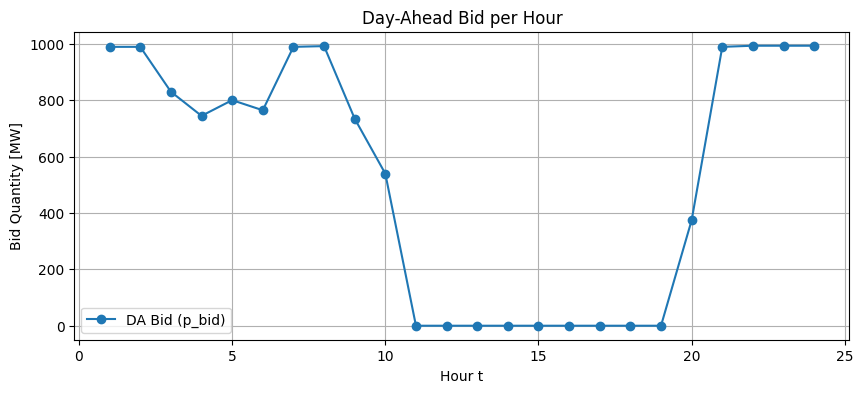

In [207]:
plt.figure(figsize=(10,4))
plt.plot(list(T), [p_bid_sol[t] for t in T], marker="o", label="DA Bid (p_bid)")
plt.xlabel("Hour t")
plt.ylabel("Bid Quantity [MW]")
plt.title("Day-Ahead Bid per Hour")
plt.grid(True)
plt.legend()
plt.show()

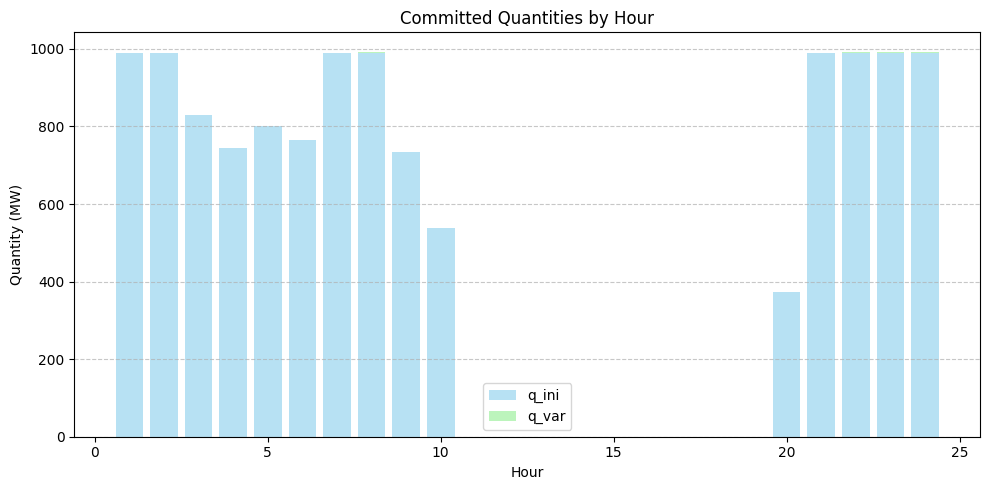

In [208]:
q_ini_hour = []
q_var_hour = []

for t in T:
    qini_sum = sum(u[t,b].X * mu_qini[(t,b)] for b in valid_blocks[t])
    qvar_sum = sum(qvar[t,b].X           for b in valid_blocks[t])
    q_ini_hour.append(qini_sum)
    q_var_hour.append(qvar_sum)

plt.figure(figsize=(10,5))
plt.bar(T, q_ini_hour, color="skyblue", alpha=0.6, label="q_ini")
plt.bar(T, q_var_hour, bottom=q_ini_hour, color="lightgreen", alpha=0.6, label="q_var")

plt.xlabel("Hour")
plt.ylabel("Quantity (MW)")
plt.title("Committed Quantities by Hour")
plt.legend()
plt.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()



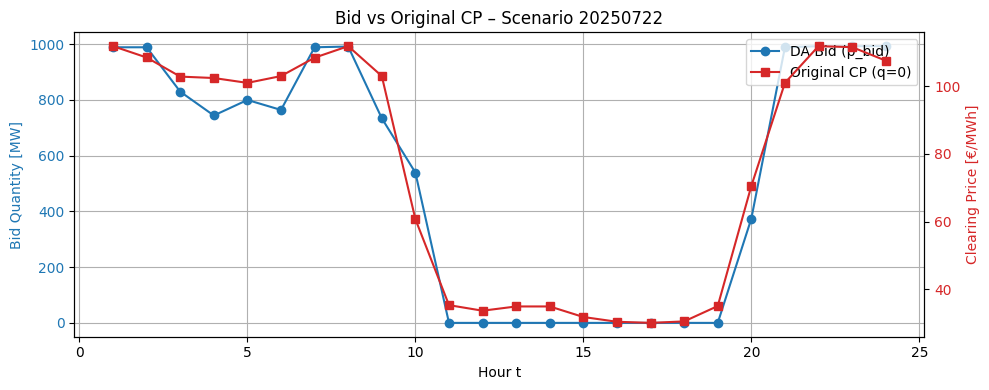

In [ ]:
scenario = "20250722"   # 보고 싶은 시나리오 날짜

fig, ax1 = plt.subplots(figsize=(10,4))

# --- Bid (좌측 y축) ---
ax1.plot(T, [p_bid_sol[t] for t in T],
         marker="o", color="tab:blue", label="DA Bid (p_bid)")
ax1.set_xlabel("Hour t")
ax1.set_ylabel("Bid Quantity [MW]", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True)

# --- Original CP (우측 y축) ---
ax2 = ax1.twinx()
cp_series = [orig_cp.get((scenario, t), np.nan) for t in T]  # nan이면 빠짐
ax2.plot(T, cp_series,
         marker="s", color="tab:red", label="Original CP (q=0)")
ax2.set_ylabel("Clearing Price [€/MWh]", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

# --- Legend 합치기 ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc="upper right")

# plt.title(f"Bid vs Original CP – Scenario {scenario}")
plt.title(f"Original Cleared Price vs  ")
plt.tight_layout()
plt.show()



[WARN] hours with no block/price for scenario='20250420': 24


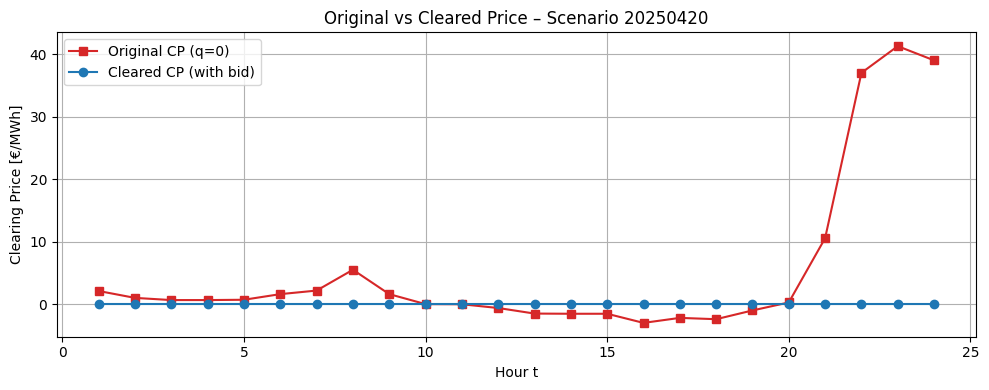

In [216]:
def get_cleared_price_for_scn(scn_key, T, valid_blocks, u, lambda_da_big):
    cleared_price = {}
    miss_cnt = 0
    for t in T:
        # 우선 시나리오-비종속 블록목록으로 돌고 (키 존재로 필터)
        blocks = [b for b in valid_blocks.get(t, [])
                  if (t,b,scn_key) in lambda_da_big]
        if not blocks:
            miss_cnt += 1
            cleared_price[t] = 0.0
            continue
        cleared_price[t] = sum(u[t,b].X * lambda_da_big[(t,b,scn_key)] for b in blocks)
    if miss_cnt > 0:
        print(f"[WARN] hours with no block/price for scenario='{scn_key}': {miss_cnt}")
    return cleared_price

# 사용 예시
scenario = "20250420"  # 또는 w 인덱스, 아래 'scn_key'가 실제 키와 동일해야 함!
cleared_price = get_cleared_price_for_scn(
    scn_key=scenario,
    T=T,
    valid_blocks=valid_blocks,           # <-- (t)->[b] 형태 권장
    u=u,
    lambda_da_big=lambda_da_big
)

# 원래 CP도 같은 키로 있는지 먼저 확인
orig_series = [orig_cp.get((scenario,t), np.nan) for t in T]
cleared_series = [cleared_price[t] for t in T]

plt.figure(figsize=(10,4))
plt.plot(T, orig_series, marker="s", label="Original CP (q=0)", color="tab:red")
plt.plot(T, cleared_series, marker="o", label="Cleared CP (with bid)", color="tab:blue")
plt.xlabel("Hour t"); plt.ylabel("Clearing Price [€/MWh]")
plt.legend(); plt.grid(True)
plt.title(f"Original vs Cleared Price – Scenario {scenario}")
plt.tight_layout(); plt.show()


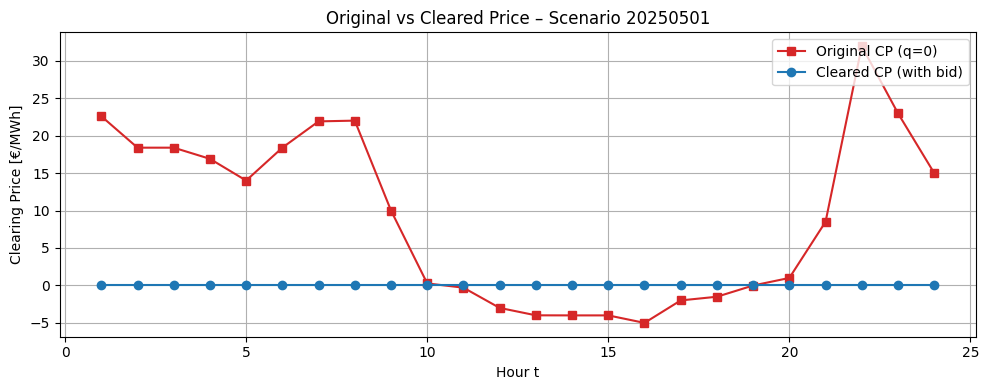

In [212]:
fig, ax = plt.subplots(figsize=(10,4))

# Original clearing price (q=0)
orig_series = [orig_cp.get((scenario,t), np.nan) for t in T]
ax.plot(T, orig_series, marker="s", color="tab:red", label="Original CP (q=0)")

# Cleared price with bid
cleared_series = [cleared_price[t] for t in T]
ax.plot(T, cleared_series, marker="o", color="tab:blue", label="Cleared CP (with bid)")

ax.set_xlabel("Hour t")
ax.set_ylabel("Clearing Price [€/MWh]")
ax.legend(loc="upper right")
ax.grid(True)
plt.title(f"Original vs Cleared Price – Scenario {scenario}")
plt.tight_layout()
plt.show()


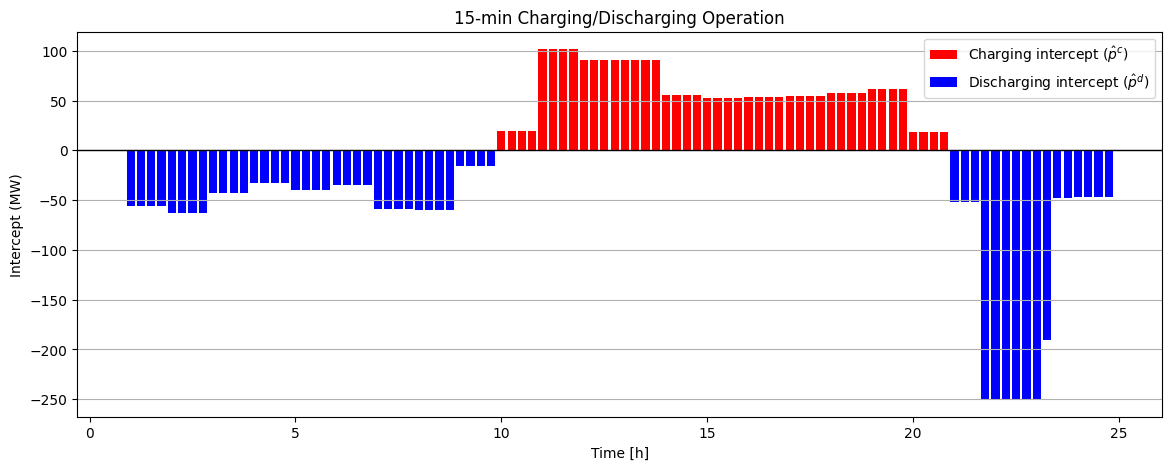

In [218]:
# flatten: (t,j) → 시간축 (1,1)=0.25h, (1,2)=0.5h ... (24,4)=24h
time_axis = [t + (j-1)/4 for t in T for j in J]

# intercept 값 펼치기
p_hat_c_vals = [p_c_mean[(t,j)] for t in T for j in J]
p_hat_d_vals = [p_d_mean[(t,j)] for t in T for j in J]

plt.figure(figsize=(14,5))

plt.bar(time_axis, p_hat_c_vals, width=0.2, color="red", label="Charging intercept ($\hat{p}^c$)")
plt.bar(time_axis, [-v for v in p_hat_d_vals], width=0.2, color="blue", label="Discharging intercept ($\hat{p}^d$)")

plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Time [h]")
plt.ylabel("Intercept (MW)")
plt.title("15-min Charging/Discharging Operation")
plt.legend()
plt.grid(True, axis="y")
plt.show()


In [148]:
print("예시 qini_big:", list(qini_big.items())[:20])
print("예시 qmax_big:", list(qmax_big.items())[:20])


예시 qini_big: [((1, 0, 0), 0.0), ((1, 1, 0), 7.96), ((1, 2, 0), 19.9), ((1, 3, 0), 27.86), ((1, 4, 0), 39.8), ((1, 5, 0), 47.76), ((1, 6, 0), 59.7), ((1, 7, 0), 67.66), ((1, 8, 0), 79.6), ((1, 9, 0), 87.56), ((1, 10, 0), 99.5), ((1, 11, 0), 107.46), ((1, 12, 0), 119.4), ((1, 13, 0), 127.36), ((1, 14, 0), 139.3), ((1, 15, 0), 147.26), ((1, 16, 0), 159.2), ((1, 17, 0), 167.16), ((1, 18, 0), 179.1), ((1, 19, 0), 187.06)]
예시 qmax_big: [((1, 0, 0), 3.98), ((1, 1, 0), 3.98), ((1, 2, 0), 3.98), ((1, 3, 0), 3.98), ((1, 4, 0), 3.980000000000004), ((1, 5, 0), 3.980000000000004), ((1, 6, 0), 3.979999999999997), ((1, 7, 0), 3.980000000000004), ((1, 8, 0), 3.980000000000004), ((1, 9, 0), 3.980000000000004), ((1, 10, 0), 3.980000000000004), ((1, 11, 0), 3.980000000000004), ((1, 12, 0), 3.9799999999999898), ((1, 13, 0), 3.980000000000004), ((1, 14, 0), 3.9799999999999898), ((1, 15, 0), 3.980000000000018), ((1, 16, 0), 3.980000000000018), ((1, 17, 0), 3.9799999999999898), ((1, 18, 0), 3.980000000000018

## RDC에 대한 VSS 구하기

In [336]:
# RDC 시나리오 집합 S(=10개)와 가중치 rho_rdc[s] (균등이면 1/|S|)
# triples[w] = (rdc_s, gen_s, rt_s)
S_rdc = list(range(len(date_range)))   # 10
S_rdc = list(range(50))   # 10

rho_rdc = {s: 1/len(S_rdc) for s in S_rdc}

# RDC만 평균 (gen/rt는 평균하지 않음)
mu_lambda_RDC = {(t,b): sum(rho_rdc[s]*lambda_da_scen_final[(t,b,s)] for s in S_rdc)
                 for t in T for b in valid_blocks[t]}
mu_qini_RDC   = {(t,b): sum(rho_rdc[s]*qini_scen_final[(t,b,s)]       for s in S_rdc)
                 for t in T for b in valid_blocks[t]}
mu_qmax_RDC   = {(t,b): sum(rho_rdc[s]*qmax_scen_final[(t,b,s)]       for s in S_rdc)
                 for t in T for b in valid_blocks[t]}

In [337]:
for t in T:
    for b in valid_blocks[t]:
        # 아무 시나리오 하나만 골라도 동일 (예: 첫 번째 시나리오 s=0)
        mu_qini_RDC[(t,b)] = qini_scen_final[(t,b,0)]
        mu_qmax_RDC[(t,b)] = qmax_scen_final[(t,b,0)]

In [338]:
# ---------------------------------------
# EV model: RDC만 EV, 나머지는 시나리오 유지
# ---------------------------------------
EV = gp.Model("EV_RDC_only")

# 1단계 변수
u_e   = EV.addVars([(t,b) for t in T for b in valid_blocks[t]], vtype=GRB.BINARY, name="u")
qv_e  = EV.addVars([(t,b) for t in T for b in valid_blocks[t]], lb=0.0, name="qvar")
p_bid_e = EV.addVars(T, lb=0.0, name="p_bid")

u_c_e = EV.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_c")
u_d_e = EV.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_d")
p_hat_c_e = EV.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_c")
p_hat_d_e = EV.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_d")
D_c_e     = EV.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_c")
D_d_e     = EV.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_d")

# 2단계 변수 (w 의존)
p_c_e = EV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pc_max, name="p_c")
p_d_e = EV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pd_max, name="p_d")
E_e   = EV.addVars([(t,j,w) for t in T for j in J for w in W], lb=E_min, ub=E_max, name="E")
p_b_e = EV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, name="p_b")

# --- 목적함수 ---
# DA: RDC 평균만 사용
DA_ev = gp.quicksum(
    mu_lambda_RDC[(t,b)] * (u_e[t,b]*mu_qini_RDC[(t,b)] + qv_e[t,b])
    for t in T for b in valid_blocks[t]
)

# RT: GEN/RT는 시나리오별
RT_ev = gp.quicksum(
    rho_w[w] * gp.quicksum(
        rt_big[(t,j,w)] * (p_b_e[t,j,w] - p_bid_e[t]/4.0)
        for j in J
    )
    for w in W for t in T
)

EV.setObjective(DA_ev + RT_ev, GRB.MAXIMIZE)

# --- 제약 ---
for t in T:
    # 블록 하나만 선택
    EV.addConstr(gp.quicksum(u_e[t,b] for b in valid_blocks[t]) == 1)

    # bid 정의
    EV.addConstr(
        p_bid_e[t] == gp.quicksum(u_e[t,b]*mu_qini_RDC[(t,b)] + qv_e[t,b]
                                  for b in valid_blocks[t])
    )

    for b in valid_blocks[t]:
        EV.addConstr(qv_e[t,b] <= mu_qmax_RDC[(t,b)] * u_e[t,b])

# 2단계 (시나리오별 balance, SOC, etc.)
for w in W:
    for t in T:
        for j in J:
            EV.addConstr(
                p_c_e[t,j,w] == u_c_e[t,j] * (p_hat_c_e[t,j] + D_c_e[t,j]*rt_big[(t,j,w)])
            )
            EV.addConstr(
                p_d_e[t,j,w] == u_d_e[t,j] * (p_hat_d_e[t,j] + D_d_e[t,j]*rt_big[(t,j,w)])
            )
            EV.addConstr(
                p_b_e[t,j,w] ==
                (gp.quicksum(pwf_big[(i,t,w)] for i in I)/4.0)
                + p_d_e[t,j,w] - p_c_e[t,j,w] - p_bid_e[t]/4.0
            )

            prev = (E0 if (t==1 and j==1) else (E_e[(t-1,4,w)] if j==1 else E_e[(t,j-1,w)]))
            EV.addConstr(E_e[t,j,w] == prev + Δt*(eta_c*p_c_e[t,j,w] - p_d_e[t,j,w]/eta_d))

    # bid 경계
    for t in T:
        EV.addConstr(-gp.quicksum(p_c_e[t,j,w] for j in J) <= p_bid_e[t])
        EV.addConstr(p_bid_e[t] <= 1000 + gp.quicksum(p_d_e[t,j,w] for j in J))
EV.Params.MIPGap = 0.00000002
EV.optimize()
Z_EV_RDC = EV.ObjVal


Set parameter MIPGap to value 2e-08
Gurobi Optimizer version 10.0.2 build v10.0.2rc0 (win64)

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 16824 rows, 29352 columns and 74230 nonzeros
Model fingerprint: 0xc1b74363
Model has 9600 quadratic constraints
Variable types: 24384 continuous, 4968 integer (4968 binary)
Coefficient statistics:
  Matrix range     [2e-01, 2e+03]
  QMatrix range    [3e-03, 4e+01]
  QLMatrix range   [1e+00, 1e+00]
  Objective range  [5e-05, 9e+04]
  Bounds range     [1e+00, 2e+03]
  RHS range        [1e+00, 1e+03]
Presolve removed 4714 rows and 8873 columns
Presolve time: 0.18s
Presolved: 21188 rows, 21631 columns, 117652 nonzeros
Presolved model has 768 SOS constraint(s)
Variable types: 16292 continuous, 5339 integer (5328 binary)
Deterministic concurrent LP optimizer: primal and dual simplex
Showing first log only...

Concurrent

In [ ]:
EEV = gp.Model("EEV_RDC_eval")

# 2단계만 변수
p_c2 = EEV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pc_max)
p_d2 = EEV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pd_max)
E2   = EEV.addVars([(t,j,w) for t in T for j in J for w in W], lb=E_min, ub=E_max)
p_b2 = EEV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0)

# EV의 1단계 해 고정값 사용
DA_eval = gp.quicksum(
    rho_w[w] * gp.quicksum(
        lambda_da_big[(t,b,w)] * (u_e[t,b].X * qini_big[(t,b,w)] + qv_e[t,b].X)
        for b in valid_blocks[t] if (t,b,w) in lambda_da_big
    )
    for w in W for t in T
)
RT_eval = gp.quicksum(
    rho_w[w] * gp.quicksum(
        rt_big[(t,j,w)] * (p_b2[t,j,w] - p_bid_e[t].X/4.0)
        for j in J
    )
    for w in W for t in T
)
EEV.setObjective(DA_eval + RT_eval, GRB.MAXIMIZE)

# LDR/균형/SOC/경계 — EV의 u_c,u_d,p_hat,D,p_bid 를 **값**으로 사용
for w in W:
  for t in T:
    for j in J:
      EEV.addConstr(p_c2[t,j,w] == u_c_e[t,j].X*(p_hat_c_e[t,j].X + D_c_e[t,j].X*rt_big[(t,j,w)]))
      EEV.addConstr(p_d2[t,j,w] == u_d_e[t,j].X*(p_hat_d_e[t,j].X + D_d_e[t,j].X*rt_big[(t,j,w)]))
      EEV.addConstr(p_b2[t,j,w] ==
                    (gp.quicksum(pwf_big[(i,t,w)] for i in I)/4.0) + p_d2[t,j,w] - p_c2[t,j,w]
                    - p_bid_e[t].X/4.0)
      prev = (E0 if (t==1 and j==1) else (E2[(t-1,4,w)] if j==1 else E2[(t,j-1,w)]))
      EEV.addConstr(E2[t,j,w] == prev + Δt*(eta_c*p_c2[t,j,w] - p_d2[t,j,w]/eta_d))
  for t in T:
      EEV.addConstr(-gp.quicksum(p_c2[t,j,w] for j in J) <= p_bid_e[t].X)
      EEV.addConstr(p_bid_e[t].X <= 1000 + gp.quicksum(p_d2[t,j,w] for j in J))
# EEV.Params.MIPGap = 0.00000002
EEV.optimize()
Z_EEV = EEV.ObjVal

Gurobi Optimizer version 10.0.2 build v10.0.2rc0 (win64)

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 21600 rows, 19200 columns and 52750 nonzeros
Model fingerprint: 0xa150cc22
Coefficient statistics:
  Matrix range     [2e-01, 1e+00]
  Objective range  [5e-05, 8e-01]
  Bounds range     [5e+02, 2e+03]
  RHS range        [2e-17, 2e+03]
Presolve removed 21600 rows and 19200 columns
Presolve time: 0.01s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    4.1639647e+05   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.01 seconds (0.01 work units)
Optimal objective  4.163964663e+05


In [329]:
VSS_RDC = Z_RP - Z_EEV
print(f"Z_RP    = {Z_RP:,.2f}")
print(f"Z_EEV   = {Z_EEV:,.2f}")
print(f"VSS(RDC)= {VSS_RDC:,.2f}")

Z_RP    = 415,753.30
Z_EEV   = 416,396.47
VSS(RDC)= -643.16


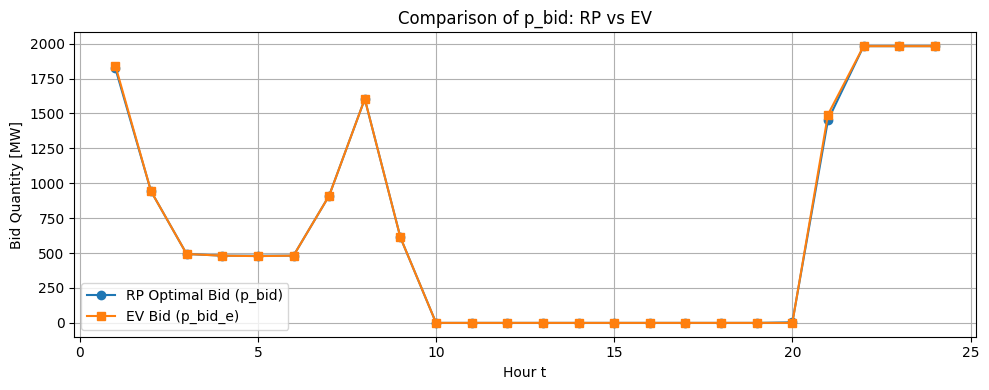

In [311]:
# --- p_bid 비교: RP 최적해 vs EV 해 ---
p_bid_RP  = [p_bid[t].X    for t in T]   # Recourse/RP 해
p_bid_EEV = [p_bid_e[t].X  for t in T]   # EV 기반 해 (EEV 평가)

plt.figure(figsize=(10,4))
plt.plot(T, p_bid_RP,  marker="o", color="tab:blue",  label="RP Optimal Bid (p_bid)")
plt.plot(T, p_bid_EEV, marker="s", color="tab:orange",label="EV Bid (p_bid_e)")
plt.xlabel("Hour t")
plt.ylabel("Bid Quantity [MW]")
plt.title("Comparison of p_bid: RP vs EV")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

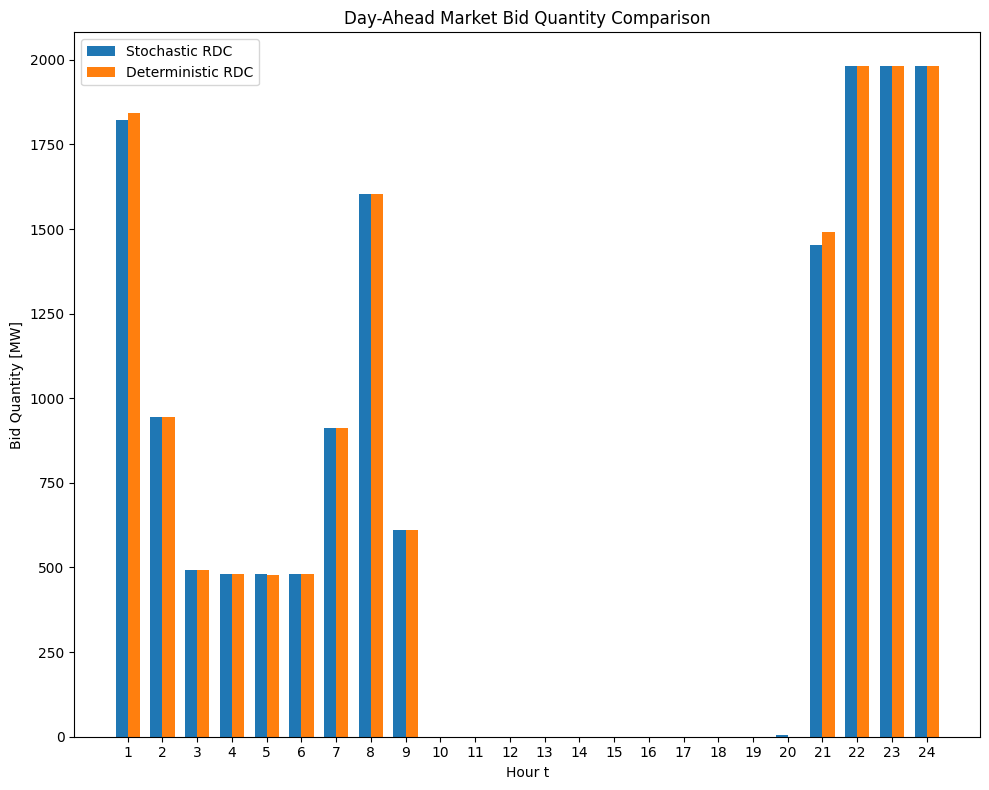

In [364]:
x = np.arange(len(T))
width = 0.35

fig, ax = plt.subplots(figsize=(10,8))
ax.bar(x - width/2, p_bid_RP,  width, label="Stochastic RDC")
ax.bar(x + width/2, p_bid_EEV, width, label="Deterministic RDC")

ax.set_xticks(x)
ax.set_xticklabels(T)
ax.set_xlabel("Hour t")
ax.set_ylabel("Bid Quantity [MW]")
ax.set_title("Day-Ahead Market Bid Quantity Comparison")
ax.legend()
plt.tight_layout()
plt.show()


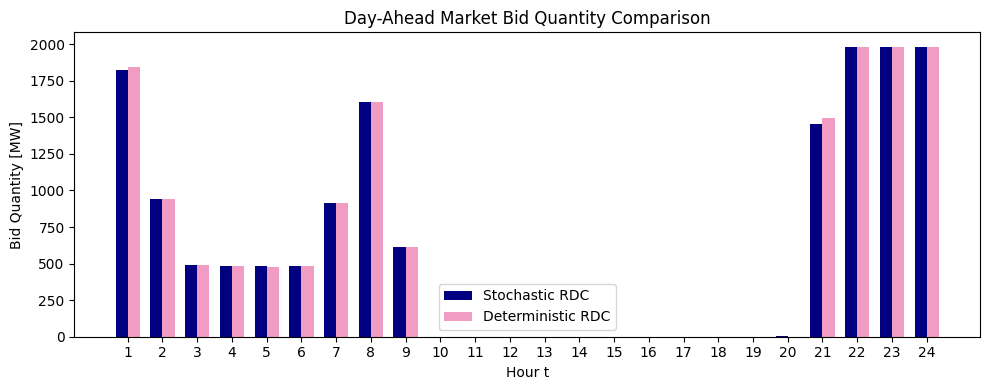

In [365]:

x = np.arange(len(T))
width = 0.35

fig, ax = plt.subplots(figsize=(10,4))

# 색상 지정: 핑크(#ffb6c1), 하늘색(#87ceeb)
ax.bar(x - width/2, p_bid_RP,  width, label="Stochastic RDC", color="#000080")
ax.bar(x + width/2, p_bid_EEV, width, label="Deterministic RDC", color="#f19DC3")
# ax.bar(x - width/2, p_bid_RP,  width, label="Stochastic RDC", color="#ffb6c1")
# ax.bar(x + width/2, p_bid_EEV, width, label="Deterministic RDC", color="#87ceeb")

ax.set_xticks(x)
ax.set_xticklabels(T)
ax.set_xlabel("Hour t")
ax.set_ylabel("Bid Quantity [MW]")
ax.set_title("Day-Ahead Market Bid Quantity Comparison")
ax.legend()
plt.tight_layout()
plt.show()

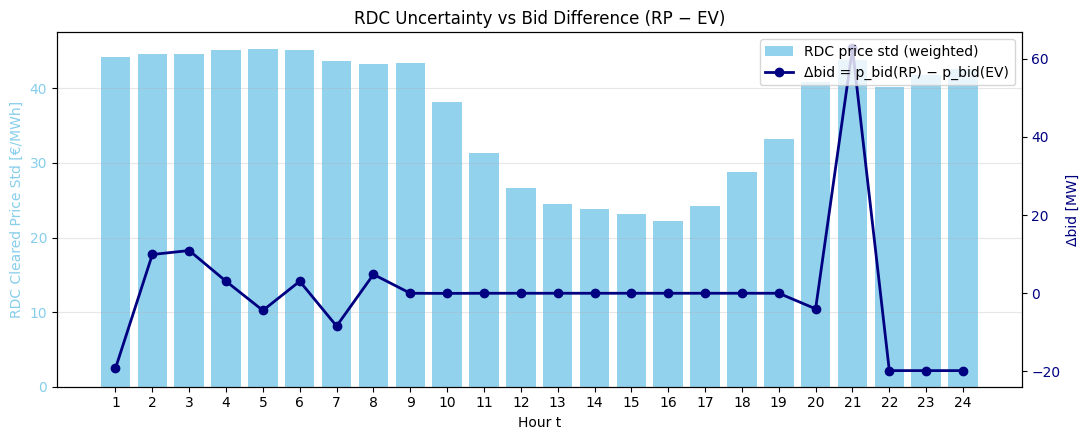

In [273]:


# ---------- 1) 시나리오별 cleared price(=RDC 기반 가격) 계산: RP 해 고정 ----------
#  λ_{t,w}^DA(RP) = Σ_b u[t,b] * lambda_da_big[(t,b,w)]
cleared_price_RP = {}  # (t,w) -> price
for t in T:
    blocks = valid_blocks.get(t, [])
    for w in W:
        val = 0.0
        for b in blocks:
            key = (t, b, w)
            if key in lambda_da_big:
                val += u[t,b].X * lambda_da_big[key]
        cleared_price_RP[(t,w)] = val

# ---------- 2) 가중 표준편차 계산(시나리오 확률 rho_w 사용) ----------
def weighted_mean_std(values, weights):
    vals = np.array(values, dtype=float)
    wts  = np.array(weights, dtype=float)
    m = np.sum(wts * vals) / (np.sum(wts) + 1e-12)
    var = np.sum(wts * (vals - m)**2) / (np.sum(wts) + 1e-12)
    return m, np.sqrt(var)

std_by_t = []   # 시간대별 (가중) 표준편차
for t in T:
    vals = [cleared_price_RP[(t,w)] for w in W]
    wts  = [rho_w[w] for w in W]
    _, s = weighted_mean_std(vals, wts)
    std_by_t.append(s)

# ---------- 3) Δbid = p_bid_RP − p_bid_EV ----------
delta_bid = [p_bid[t].X - p_bid_e[t].X for t in T]

# ---------- 4) 플롯: 표준편차(하늘색 bar) + Δbid(남색 라인) ----------
x = np.arange(len(T))
fig, ax1 = plt.subplots(figsize=(11,4.5))

# 불확실성(가격 표준편차) - 하늘색 막대
ax1.bar(x, std_by_t, color="#87ceeb", alpha=0.9, label="RDC price std (weighted)")
ax1.set_ylabel("RDC Cleared Price Std [€/MWh]", color="#87ceeb")
ax1.tick_params(axis="y", labelcolor="#87ceeb")
ax1.set_xlabel("Hour t")
ax1.set_xticks(x)
ax1.set_xticklabels(T)
ax1.grid(True, axis="y", alpha=0.3)

# Δbid - 남색 라인(우측 축)
ax2 = ax1.twinx()
ax2.plot(x, delta_bid, marker="o", linewidth=2.0, color="#000080",
         label="Δbid = p_bid(RP) − p_bid(EV)")
ax2.set_ylabel("Δbid [MW]", color="#000080")
ax2.tick_params(axis="y", labelcolor="#000080")

# 범례 합치기
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title("RDC Uncertainty vs Bid Difference (RP − EV)")
plt.tight_layout()
plt.show()


In [12]:
# ---- 유효블록: 모든 시나리오에서 등장한 블록의 합집합 (RDC를 평균으로 쓸 것이므로 t별 단일 집합) ----
valid_blocks_EV = {
    t: sorted({b for (tt,b,ww) in qini_big.keys() if tt == t})
    for t in T
}

# ---- RDC 파라미터 기대값 (w에 대해 평균) ----
mu_lambda_RDC = {
    (t,b): sum(rho_w[w]*lambda_da_big[(t,b,w)] for w in W if (t,b,w) in lambda_da_big)
    for t in T for b in valid_blocks_EV[t]
}
mu_qini_RDC = {
    (t,b): sum(rho_w[w]*qini_big[(t,b,w)] for w in W if (t,b,w) in qini_big)
    for t in T for b in valid_blocks_EV[t]
}
mu_qmax_RDC = {
    (t,b): sum(rho_w[w]*qmax_big[(t,b,w)] for w in W if (t,b,w) in qmax_big)
    for t in T for b in valid_blocks_EV[t]
}


In [13]:
mu_lq_RDC = {
    (t,b): sum(rho_w[w] * lambda_da_big[(t,b,w)] * qini_big[(t,b,w)]
               for w in W if (t,b,w) in lambda_da_big and (t,b,w) in qini_big)
    for t in T for b in valid_blocks_EV[t]
}

In [14]:
#2
def build_and_solve_EV_RDC():
    m = gp.Model("EV_RDC_only")

    # ---------- 블록 집합(시나리오 비의존) ----------
    # valid_blocks_EV 는 valid_blocks 와 동일해야 함
    # valid_blocks_EV[t] 가 없다면 valid_blocks[t] 를 그대로 쓰세요.
    assert all(t in valid_blocks_EV for t in T)

    # ---------- 0) qmax '최악치' 사전 계산 (RP/EV/EEV 모두 동일하게) ----------
    # qmax_worst[(t,b)] = min_w qmax[(t,b,w)]
    qmax_worst = {
        (t,b): min(qmax_big[(t,b,w)] for w in W if (t,b,w) in qmax_big)
        for t in T for b in valid_blocks_EV[t]
    }

    # ---------- 1단계 ----------
    u_ev     = m.addVars([(t,b) for t in T for b in valid_blocks_EV[t]], vtype=GRB.BINARY, name="u")
    qvar_ev  = m.addVars([(t,b) for t in T for b in valid_blocks_EV[t]], lb=0.0, name="qvar")
    p_bid_ev = m.addVars(T, lb=0.0, name="p_bid")

    # ESS on/off (공통)
    u_c_ev = m.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_c")
    u_d_ev = m.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_d")

    # ---------- 2단계 ----------
    p_c_ev = m.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pc_max, name="p_c")
    p_d_ev = m.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pd_max, name="p_d")
    E_q_ev = m.addVars([(t,j,w) for t in T for j in J for w in W], lb=E_min, ub=E_max, name="E_q")
    p_b_ev = m.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, name="p_b")

    # LDR 계수(공통)
    p_hat_c_ev = m.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_c")
    p_hat_d_ev = m.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_d")
    D_c_ev     = m.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_c")
    D_d_ev     = m.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_d")

    # ---------- 목적함수 ----------
    # DA (RDC만 평균)
    # EV 목적함수: E[λ·qini] 직접 사용
    DA_rev_EV = gp.quicksum(
        mu_lq_RDC[(t,b)] * u_ev[t,b] + mu_lambda_RDC[(t,b)] * qvar_ev[t,b]
        for t in T for b in valid_blocks_EV[t]
    )

    # DA_rev_EV = gp.quicksum(
    #     mu_lambda_RDC[(t,b)] * (u_ev[t,b]*mu_qini_RDC[(t,b)] + qvar_ev[t,b])
    #     for t in T for b in valid_blocks_EV[t]
    # )
    # RT (w-시나리오)
    RT_rev_EV = gp.quicksum(
        rho_w[w] * gp.quicksum(
            rt_big[(t,j,w)] * (p_b_ev[t,j,w] - p_bid_ev[t]/4.0)
            for t in T for j in J
        )
        for w in W
    )
    m.setObjective(DA_rev_EV + RT_rev_EV, GRB.MAXIMIZE)

    # ---------- 제약 ----------
    # (i) 실시간 균형
    for w in W:
        for t in T:
            for j in J:
                m.addConstr(
                    p_b_ev[t,j,w] ==
                    (gp.quicksum(pwf_big[(i,t,w)] for i in I)/4.0) + p_d_ev[t,j,w] - p_c_ev[t,j,w]
                    - p_bid_ev[t]/4.0,
                    name=f"bal_EV_{t}_{j}_w{w}"
                )

    # (ii) t마다 블록 하나
    for t in T:
        m.addConstr(gp.quicksum(u_ev[t,b] for b in valid_blocks_EV[t]) == 1, name=f"one_block_EV_{t}")

    # (iii) qvar 상한 — ★ 세 모델 공통: 최악치로 통일 ★
    for t in T:
        for b in valid_blocks_EV[t]:
            m.addConstr(qvar_ev[t,b] <= qmax_worst[(t,b)] * u_ev[t,b], name=f"qvar_worst_EV_{t}_{b}")

    # (iv) p_bid 정의 — μ(qini)
    for t in T:
        m.addConstr(
            p_bid_ev[t] == gp.quicksum(u_ev[t,b]*mu_qini_RDC[(t,b)] + qvar_ev[t,b]
                                       for b in valid_blocks_EV[t]),
            name=f"p_bid_def_EV_{t}"
        )

    # (v) LDR
    for w in W:
        for t in T:
            for j in J:
                lam_rt = rt_big[(t,j,w)]
                m.addConstr(p_c_ev[t,j,w] == u_c_ev[t,j]*(p_hat_c_ev[t,j] + D_c_ev[t,j]*lam_rt),
                            name=f"LDRc_EV_{t}_{j}_w{w}")
                m.addConstr(p_d_ev[t,j,w] == u_d_ev[t,j]*(p_hat_d_ev[t,j] + D_d_ev[t,j]*lam_rt),
                            name=f"LDRd_EV_{t}_{j}_w{w}")

    # (vi) 동시충방전 금지 + Big-M
    for t in T:
        for j in J:
            m.addConstr(u_c_ev[t,j] + u_d_ev[t,j] <= 1, name=f"no_simul_EV_{t}_{j}")
            for w in W:
                m.addConstr(p_c_ev[t,j,w] <= pc_max * u_c_ev[t,j], name=f"pcM_EV_{t}_{j}_w{w}")
                m.addConstr(p_d_ev[t,j,w] <= pd_max * u_d_ev[t,j], name=f"pdM_EV_{t}_{j}_w{w}")

    # (vii) SOC
    for w in W:
        for t in T:
            for j in J:
                prev = (E0 if (t == 1 and j == 1) else (E_q_ev[t-1,4,w] if j == 1 else E_q_ev[t,j-1,w]))
                m.addConstr(E_q_ev[t,j,w] == prev + Δt*(eta_c*p_c_ev[t,j,w] - p_d_ev[t,j,w]/eta_d),
                            name=f"SOC_EV_{t}_{j}_w{w}")

    # (viii) p_bid 경계
    for w in W:
        for t in T:
            m.addConstr(-gp.quicksum(p_c_ev[t,j,w] for j in J) <= p_bid_ev[t], name=f"bid_low_EV_{t}_w{w}")
            m.addConstr(p_bid_ev[t] <= 1000 + gp.quicksum(p_d_ev[t,j,w] for j in J),
                        name=f"bid_up_EV_{t}_w{w}")

    # ---------- 풀기 ----------
    m.Params.MIPGap = 2e-8
    m.optimize()

    return {
        "model": m,
        "Z_EV": m.objVal,
        "u": m.getAttr("x", u_ev),
        "qvar": m.getAttr("x", qvar_ev),
        "p_bid": m.getAttr("x", p_bid_ev),
        "u_c": m.getAttr("x", u_c_ev),
        "u_d": m.getAttr("x", u_d_ev),
        "p_hat_c": m.getAttr("x", p_hat_c_ev),
        "p_hat_d": m.getAttr("x", p_hat_d_ev),
        "D_c": m.getAttr("x", D_c_ev),
        "D_d": m.getAttr("x", D_d_ev),
        "qmax_worst": qmax_worst,  # EEV/RP에서도 동일 사용
    }


In [15]:
def evaluate_EEV_RDC(ev_sol, qmax_worst):
    m = gp.Model("EEV_RDC_only_clean")

    # ---------- 2단계 변수만 ----------
    p_c = m.addVars([(t,j,w) for t in T for j in J for w in W],
                    lb=0.0, ub=pc_max, name="p_c")
    p_d = m.addVars([(t,j,w) for t in T for j in J for w in W],
                    lb=0.0, ub=pd_max, name="p_d")
    E_q = m.addVars([(t,j,w) for t in T for j in J for w in W],
                    lb=E_min, ub=E_max, name="E_q")
    p_b = m.addVars([(t,j,w) for t in T for j in J for w in W],
                    lb=0.0, name="p_b")

    # ---------- 목적함수 ----------
    DA_eval = gp.quicksum(
        rho_w[w] * gp.quicksum(
            lambda_da_big[(t,b,w)] *
            (ev_sol["u"][(t,b)] * qini_big[(t,b,w)] + ev_sol["qvar"][(t,b)])
            for b in valid_blocks_by_w.get((t,w), [])
            if (t,b,w) in lambda_da_big
        )
        for w in W for t in T
    )

    RT_eval = gp.quicksum(
        rho_w[w] * gp.quicksum(
            rt_big[(t,j,w)] * (p_b[(t,j,w)] - ev_sol["p_bid"][t]/4.0)
            for j in J
        )
        for w in W for t in T
    )

    m.setObjective(DA_eval + RT_eval, GRB.MAXIMIZE)

    # ---------- 제약 ----------
    # (1) 실시간 전력균형
    for w in W:
        for t in T:
            for j in J:
                m.addConstr(
                    p_b[(t,j,w)] ==
                    (gp.quicksum(pwf_big[(i,t,w)] for i in I)/4.0)
                    + p_d[(t,j,w)] - p_c[(t,j,w)]
                    - ev_sol["p_bid"][t]/4.0,
                    name=f"bal_{t}_{j}_w{w}"
                )

    # (2) LDR (EV 해 고정)
    for w in W:
        for t in T:
            for j in J:
                lam_rt = rt_big[(t,j,w)]
                m.addConstr(
                    p_c[(t,j,w)] ==
                    ev_sol["u_c"][(t,j)] * (ev_sol["p_hat_c"][(t,j)] + ev_sol["D_c"][(t,j)]*lam_rt),
                    name=f"LDRc_{t}_{j}_w{w}"
                )
                m.addConstr(
                    p_d[(t,j,w)] ==
                    ev_sol["u_d"][(t,j)] * (ev_sol["p_hat_d"][(t,j)] + ev_sol["D_d"][(t,j)]*lam_rt),
                    name=f"LDRd_{t}_{j}_w{w}"
                )

    # (3) SOC
    for w in W:
        for t in T:
            for j in J:
                prev = (E0 if (t==1 and j==1) else (E_q[(t-1,4,w)] if j==1 else E_q[(t,j-1,w)]))
                m.addConstr(
                    E_q[(t,j,w)] == prev + Δt*(eta_c*p_c[(t,j,w)] - p_d[(t,j,w)]/eta_d),
                    name=f"SOC_{t}_{j}_w{w}"
                )

    # (4) DA-RT 연계
    for w in W:
        for t in T:
            m.addConstr(-gp.quicksum(p_c[(t,j,w)] for j in J) <= ev_sol["p_bid"][t],
                        name=f"bid_low_{t}_w{w}")
            m.addConstr(ev_sol["p_bid"][t] <= 1000 + gp.quicksum(p_d[(t,j,w)] for j in J),
                        name=f"bid_up_{t}_w{w}")

    m.Params.MIPGap = 2e-8
    m.optimize()
    return m.objVal


In [16]:
# # ① 원래 SP(네가 가진 모델) 먼저 풀어서 Z_SP 확보
# model.optimize()
# Z_SP = model.objVal

# ① EV 풀기
ev_sol = build_and_solve_EV_RDC()
print("Z_EV (RDC only):", ev_sol["Z_EV"])

# ② EEV (EV로 고정한 상태에서 시나리오별 재평가)
Z_EEV_RDC = evaluate_EEV_RDC(ev_sol, ev_sol["qmax_worst"])
print("Z_EEV (RDC only):", Z_EEV_RDC)

# ③ VSS 계산
# VSS = ev_sol["Z_EV"] - Z_EEV_RDC
# print(f"VSS(RDC only): {VSS:.2f}")


Set parameter MIPGap to value 2e-08
Gurobi Optimizer version 10.0.2 build v10.0.2rc0 (win64)

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 48120 rows, 48552 columns and 163172 nonzeros
Model fingerprint: 0xe2980b90
Model has 19200 quadratic constraints
Variable types: 43584 continuous, 4968 integer (4968 binary)
Coefficient statistics:
  Matrix range     [2e-01, 2e+03]
  QMatrix range    [3e-03, 5e+01]
  QLMatrix range   [1e+00, 1e+00]
  Objective range  [3e-05, 1e+05]
  Bounds range     [1e+00, 2e+03]
  RHS range        [1e+00, 1e+03]
Presolve removed 7504 rows and 13963 columns
Presolve time: 0.66s
Presolved: 58514 rows, 35741 columns, 239800 nonzeros
Presolved model has 768 SOS constraint(s)
Variable types: 31206 continuous, 4535 integer (4535 binary)
Found heuristic solution: objective 467721.55665
Root relaxation presolved: 48590 rows, 25521 col

# 최적화: 0930

In [5]:
valid_blocks = {t: [] for t in range(1,25)}
for (t,b,w), val in qmax_big.items():
    if val > 0:
        valid_blocks[t].append(b)
valid_blocks = {t: sorted(set(bs)) for t, bs in valid_blocks.items()}

In [6]:
eta_c, eta_d    = 0.9, 0.9
E0, E_min, E_max = 1400, 500, 2250
pc_max, pd_max  = 500, 500
# pc_max, pd_max  = 1000, 1000

Δt = 0.25

In [7]:
S = list(range(100))                        # 시나리오 index
T = list(range(1, 25))                                  # 시간
I = [0]
J = [1,2,3,4]
Δt = 0.25
rho_w = {s: 1/len(S) for s in S}        

In [8]:
model = gp.Model("WF_ESS_3D_RDC_RT_WF")

# ---------- 1단계(H&N) ----------
u = model.addVars([(t,b) for t in T for b in valid_blocks[t]],
                  vtype=GRB.BINARY, name="u")

qvar  = model.addVars([(t,b) for t in T for b in valid_blocks[t]],
                      lb=0.0, name="qvar")
p_bid = model.addVars(T, lb=0.0, name="p_bid")

# ESS on/off (H&N)
u_c = model.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_c")
u_d = model.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_d")

# ---------- 2단계(Recourse; w별) ----------
p_c = model.addVars([(t,j,w) for t in T for j in J for w in W],
                    lb=0.0, ub=pc_max, name="p_c")
p_d = model.addVars([(t,j,w) for t in T for j in J for w in W],
                    lb=0.0, ub=pd_max, name="p_d")
E_q = model.addVars([(t,j,w) for t in T for j in J for w in W],
                    lb=E_min, ub=E_max, name="E_q")
p_b = model.addVars([(t,j,w) for t in T for j in J for w in W],
                    lb=0.0, name="p_b")

# LDR 계수(공통)
p_hat_c = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_c")
p_hat_d = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_d")
D_c     = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_c")
D_d     = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_d")

# ---------- 목적함수 ----------
DA_rev = gp.quicksum(
    rho_w[w] * gp.quicksum(
        lambda_da_big[(t,b,w)] * (u[t,b] * qini_big[(t,b,w)] + qvar[t,b])
        for b in valid_blocks_by_w.get((t,w), [])
        if (t,b,w) in lambda_da_big
    )
    for w in W for t in T
)

RT_rev = gp.quicksum(
    rho_w[w] * gp.quicksum(
        rt_big[(t,j,w)] * (p_b[(t,j,w)] - p_bid[t]/4.0)
        for j in J if (t,j,w) in rt_big
    )
    for w in W for t in T
)

model.setObjective(DA_rev + RT_rev, GRB.MAXIMIZE)

# ---------- 제약식 ----------
# (6b) 실시간 균형
for w in W:
    for t in T:
        for j in J:
            model.addConstr(
                p_b[(t,j,w)] ==
                (gp.quicksum(pwf_big[(i,t,w)] for i in I)/4.0)
                + p_d[(t,j,w)] - p_c[(t,j,w)]
                - p_bid[t]/4.0,
                name=f"rt_balance_{t}_{j}_w{w}"
            )

# (6c) 매 시각 블록 하나 선택
for t in T:
    model.addConstr(gp.quicksum(u[t,b] for b in valid_blocks[t]) == 1,
                    name=f"one_block_{t}")

# # (6d) qvar 상한
# for w in W:
#     for t in T:
#         for b in valid_blocks_by_w.get((t,w), []):
#             model.addConstr(
#                 qvar[t,b] <= qmax_big[(t,b,w)] * u[t,b],
#                 name=f"qvar_max_{t}_{b}_w{w}"
#             )
# (6d) qvar 상한
for w in W:
    for t in T:
        for b in valid_blocks_by_w.get((t,w), []):
            model.addConstr(
                qvar[t,b] <= 10,
                name=f"qvar_max_{t}_{b}_w{w}"
            )
# (6e) p_bid 정의 (평균 qini 사용)
mu_qini = {
    (t,b): sum(rho_w[w]*qini_big[(t,b,w)] for w in W if (t,b,w) in qini_big)
    for t in T for b in valid_blocks[t]
}
for t in T:
    model.addConstr(
        p_bid[t] == gp.quicksum(u[t,b]*mu_qini[(t,b)] + qvar[t,b]
                                for b in valid_blocks[t]),
        name=f"p_bid_def_{t}"
    )

# (6h), (6i) LDR
for w in W:
    for t in T:
        for j in J:
            model.addConstr(
                p_c[(t,j,w)] == u_c[(t,j)] * (p_hat_c[(t,j)] + D_c[(t,j)] * rt_big[(t,j,w)]),
                name=f"LDR_pc_{t}_{j}_w{w}"
            )
            model.addConstr(
                p_d[(t,j,w)] == u_d[(t,j)] * (p_hat_d[(t,j)] + D_d[(t,j)] * rt_big[(t,j,w)]),
                name=f"LDR_pd_{t}_{j}_w{w}"
            )

# (6k) 동시 충방전 금지 + Big-M
for t in T:
    for j in J:
        model.addConstr(u_c[(t,j)] + u_d[(t,j)] <= 1, name=f"no_simul_{t}_{j}")
        for w in W:
            model.addConstr(p_c[(t,j,w)] <= pc_max * u_c[(t,j)], name=f"pc_bigm_{t}_{j}_w{w}")
            model.addConstr(p_d[(t,j,w)] <= pd_max * u_d[(t,j)], name=f"pd_bigm_{t}_{j}_w{w}")

# (6j) SOC 전이
for w in W:
    for t in T:
        for j in J:
            prev = (E0 if (t == 1 and j == 1)
                    else (E_q[(t-1,4,w)] if j == 1 else E_q[(t,j-1,w)]))
            model.addConstr(
                E_q[(t,j,w)] == prev + Δt*(eta_c*p_c[(t,j,w)] - p_d[(t,j,w)]/eta_d),
                name=f"SOC_{t}_{j}_w{w}"
            )

# (6g) DA vs RT 경계
for w in W:
    for t in T:
        rhs = gp.quicksum(pwf_big[(i,t,w)] for i in I) + gp.quicksum(p_d[(t,j,w)] for j in J)
        model.addConstr(-gp.quicksum(p_c[(t,j,w)] for j in J) <= p_bid[t],
                        name=f"bid_low_{t}_w{w}")
        model.addConstr(p_bid[t] <= rhs, name=f"bid_up_{t}_w{w}")

# (6l), (6m) 충/방전 용량 상한
for w in W:
    for t in T:
        model.addConstr(
            gp.quicksum(D_c[(t,j)] * rt_big[(t,j,w)] + p_hat_c[(t,j)] for j in J)
            <= pc_max,
            name=f"cap_charge_{t}_w{w}"
        )
        model.addConstr(
            gp.quicksum(D_d[(t,j)] * rt_big[(t,j,w)] + p_hat_d[(t,j)] for j in J)
            <= pd_max,
            name=f"cap_discharge_{t}_w{w}"
        )

# ---------- 옵션 ----------
model.Params.MIPGap = 0.005
model.optimize()
Z_RP = model.ObjVal


Set parameter Username
Set parameter LicenseID to value 2665974
Academic license - for non-commercial use only - expires 2026-05-14
Set parameter MIPGap to value 0.005
Gurobi Optimizer version 10.0.2 build v10.0.2rc0 (win64)

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 525744 rows, 48552 columns and 668982 nonzeros
Model fingerprint: 0xc0afc198
Model has 19200 quadratic constraints
Variable types: 43584 continuous, 4968 integer (4968 binary)
Coefficient statistics:
  Matrix range     [3e-03, 2e+03]
  QMatrix range    [3e-03, 5e+01]
  QLMatrix range   [1e+00, 1e+00]
  Objective range  [3e-05, 1e+05]
  Bounds range     [1e+00, 2e+03]
  RHS range        [1e+00, 2e+03]
Presolve removed 449075 rows and 13833 columns
Presolve time: 2.06s
Presolved: 77197 rows, 34851 columns, 362488 nonzeros
Variable types: 32142 continuous, 2709 integer (2709 binary)
Foun

In [9]:
def build_and_solve_EV_RDC():
    m = gp.Model("EV_RDC_only")

    # ---------- 블록 집합 ----------
    valid_blocks_EV = {
        t: sorted({b for (tt,b,ww) in qini_big.keys() if tt == t})
        for t in T
    }

    # ---------- 평균 파라미터 ----------
    mu_qini = {(t,b): sum(rho_w[w]*qini_big[(t,b,w)] for w in W if (t,b,w) in qini_big)
               for t in T for b in valid_blocks_EV[t]}
    mu_qmax = {(t,b): sum(rho_w[w]*qmax_big[(t,b,w)] for w in W if (t,b,w) in qmax_big)
               for t in T for b in valid_blocks_EV[t]}
    mu_lambda = {(t,b): sum(rho_w[w]*lambda_da_big[(t,b,w)] for w in W if (t,b,w) in lambda_da_big)
                 for t in T for b in valid_blocks_EV[t]}

    # ---------- 1단계 ----------
    u_ev     = m.addVars([(t,b) for t in T for b in valid_blocks_EV[t]], vtype=GRB.BINARY, name="u")
    qvar_ev  = m.addVars([(t,b) for t in T for b in valid_blocks_EV[t]], lb=0.0, name="qvar")
    p_bid_ev = m.addVars(T, lb=0.0, name="p_bid")

    u_c_ev = m.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_c")
    u_d_ev = m.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_d")

    # ---------- 2단계 ----------
    p_c_ev = m.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pc_max, name="p_c")
    p_d_ev = m.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pd_max, name="p_d")
    E_q_ev = m.addVars([(t,j,w) for t in T for j in J for w in W], lb=E_min, ub=E_max, name="E_q")
    p_b_ev = m.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, name="p_b")

    p_hat_c_ev = m.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_c")
    p_hat_d_ev = m.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_d")
    D_c_ev     = m.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_c")
    D_d_ev     = m.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_d")

    # ---------- 목적함수 ----------
    DA_rev_EV = gp.quicksum(
        mu_lambda[(t,b)] * (u_ev[t,b]*mu_qini[(t,b)] + qvar_ev[t,b])
        for t in T for b in valid_blocks_EV[t]
    )
    RT_rev_EV = gp.quicksum(
        rho_w[w] * gp.quicksum(
            rt_big[(t,j,w)] * (p_b_ev[t,j,w] - p_bid_ev[t]/4.0)
            for j in J
        )
        for w in W for t in T
    )
    m.setObjective(DA_rev_EV + RT_rev_EV, GRB.MAXIMIZE)

    # ---------- 제약 ----------
    # ---------- 제약 ----------

    # (0) 보조: 전역 qmax 캡(최소치) — EV라도 안전장치로 권장
    qmax_cap = {
        (t,b): min(qmax_big[(t,b,w)] for w in W if (t,b,w) in qmax_big)
        for t in T for b in valid_blocks_EV[t]
    }

    # (6b) 실시간 전력균형
    for w in W:
        for t in T:
            for j in J:
                m.addConstr(
                    p_b_ev[t,j,w] ==
                    (gp.quicksum(pwf_big[(i,t,w)] for i in I) / 4.0)  # 15분 평균 풍력
                    + p_d_ev[t,j,w] - p_c_ev[t,j,w]
                    - p_bid_ev[t]/4.0,                                # DA 약속의 1/4
                    name=f"bal_EV_{t}_{j}_w{w}"
                )

    # (6c) 매 시각 블록 하나 선택
    for t in T:
        m.addConstr(gp.quicksum(u_ev[t,b] for b in valid_blocks_EV[t]) == 1,
                    name=f"one_block_EV_{t}")

    # (6d) qvar 상한 — EV는 평균 qmax로, + 전역(min) 캡 추가(권장)
    for t in T:
        for b in valid_blocks_EV[t]:
            m.addConstr(qvar_ev[t,b] <= mu_qmax[(t,b)] * u_ev[t,b],
                        name=f"qvar_mu_EV_{t}_{b}")
            m.addConstr(qvar_ev[t,b] <= qmax_cap[(t,b)] * u_ev[t,b],
                        name=f"qvar_cap_global_EV_{t}_{b}")

    # (6e) p_bid 정의 — 평균 qini 사용
    for t in T:
        m.addConstr(
            p_bid_ev[t] == gp.quicksum(u_ev[t,b]*mu_qini[(t,b)] + qvar_ev[t,b]
                                    for b in valid_blocks_EV[t]),
            name=f"p_bid_def_EV_{t}"
        )

    # (6h),(6i) LDR (EV도 시나리오별 λ_rt를 사용)
    for w in W:
        for t in T:
            for j in J:
                lam_rt = rt_big[(t,j,w)]
                m.addConstr(
                    p_c_ev[t,j,w] == u_c_ev[t,j] * (p_hat_c_ev[t,j] + D_c_ev[t,j]*lam_rt),
                    name=f"LDRc_EV_{t}_{j}_w{w}"
                )
                m.addConstr(
                    p_d_ev[t,j,w] == u_d_ev[t,j] * (p_hat_d_ev[t,j] + D_d_ev[t,j]*lam_rt),
                    name=f"LDRd_EV_{t}_{j}_w{w}"
                )

    # (6k) 동시 충방전 금지 + Big-M 링크
    for t in T:
        for j in J:
            m.addConstr(u_c_ev[t,j] + u_d_ev[t,j] <= 1, name=f"no_simul_EV_{t}_{j}")
            for w in W:
                m.addConstr(p_c_ev[t,j,w] <= pc_max * u_c_ev[t,j], name=f"pcM_EV_{t}_{j}_w{w}")
                m.addConstr(p_d_ev[t,j,w] <= pd_max * u_d_ev[t,j], name=f"pdM_EV_{t}_{j}_w{w}")

    # (6j) SOC 전이
    for w in W:
        for t in T:
            for j in J:
                prev = (E0 if (t == 1 and j == 1)
                        else (E_q_ev[t-1,4,w] if j == 1 else E_q_ev[t,j-1,w]))
                m.addConstr(
                    E_q_ev[t,j,w] == prev + Δt*(eta_c*p_c_ev[t,j,w] - p_d_ev[t,j,w]/eta_d),
                    name=f"SOC_EV_{t}_{j}_w{w}"
                )

    # (6g) DA vs RT 약속 경계 — 상수 1000 제거, 풍력총량 사용
    for w in W:
        for t in T:
            wind_t_w = gp.quicksum(pwf_big[(i,t,w)] for i in I)
            m.addConstr(-gp.quicksum(p_c_ev[t,j,w] for j in J) <= p_bid_ev[t],
                        name=f"bid_low_EV_{t}_w{w}")
            m.addConstr(p_bid_ev[t] <= wind_t_w + gp.quicksum(p_d_ev[t,j,w] for j in J),
                        name=f"bid_up_EV_{t}_w{w}")

    # (6l),(6m) LDR-기인 설비용량 상한 (시나리오별 λ_rt에 대해 항상)
    for w in W:
        for t in T:
            m.addConstr(
                gp.quicksum(D_c_ev[t,j]*rt_big[(t,j,w)] + p_hat_c_ev[t,j] for j in J) <= pc_max,
                name=f"cap_charge_EV_{t}_w{w}"
            )
            m.addConstr(
                gp.quicksum(D_d_ev[t,j]*rt_big[(t,j,w)] + p_hat_d_ev[t,j] for j in J) <= pd_max,
                name=f"cap_discharge_EV_{t}_w{w}"
            )

    # (6n) SOC bounds는 변수 생성 시 lb/ub로 이미 반영됨
    # (권장) LDR 계수에 현실적 상한도 추가해 유연성 과다 방지
    for t in T:
        for j in J:
            m.addConstr(p_hat_c_ev[t,j] <= pc_max, name=f"p_hat_c_cap_EV_{t}_{j}")
            m.addConstr(p_hat_d_ev[t,j] <= pd_max, name=f"p_hat_d_cap_EV_{t}_{j}")
            m.addConstr(D_c_ev[t,j] <= pc_max,     name=f"D_c_cap_EV_{t}_{j}")
            m.addConstr(D_d_ev[t,j] <= pd_max,     name=f"D_d_cap_EV_{t}_{j}")


    m.Params.MIPGap = 0.005
    m.optimize()

    return {
        "model": m,
        "Z_EV": m.objVal,
        "u": m.getAttr("x", u_ev),
        "qvar": m.getAttr("x", qvar_ev),
        "p_bid": m.getAttr("x", p_bid_ev),
        "u_c": m.getAttr("x", u_c_ev),
        "u_d": m.getAttr("x", u_d_ev),
        "p_hat_c": m.getAttr("x", p_hat_c_ev),
        "p_hat_d": m.getAttr("x", p_hat_d_ev),
        "D_c": m.getAttr("x", D_c_ev),
        "D_d": m.getAttr("x", D_d_ev),
    }


In [10]:
def evaluate_EEV_RDC(ev_sol):
    m = gp.Model("EEV_RDC_only")

    # 2단계 변수
    p_c = m.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pc_max, name="p_c")
    p_d = m.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pd_max, name="p_d")
    E_q = m.addVars([(t,j,w) for t in T for j in J for w in W], lb=E_min, ub=E_max, name="E_q")
    p_b = m.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, name="p_b")

    # DA profit (고정된 EV해 사용)
    DA_eval = gp.quicksum(
        rho_w[w] * gp.quicksum(
            lambda_da_big[(t,b,w)] *
            (ev_sol["u"][(t,b)] * qini_big[(t,b,w)] + ev_sol["qvar"][(t,b)])
            for b in valid_blocks_by_w.get((t,w), [])
            if (t,b,w) in lambda_da_big
        )
        for w in W for t in T
    )
    # RT profit
    RT_eval = gp.quicksum(
        rho_w[w] * gp.quicksum(
            rt_big[(t,j,w)] * (p_b[(t,j,w)] - ev_sol["p_bid"][t]/4.0)
            for j in J
        )
        for w in W for t in T
    )
    m.setObjective(DA_eval + RT_eval, GRB.MAXIMIZE)

    # 제약: balance, LDR, SOC, bid bounds (EV 해 고정)
    for w in W:
        for t in T:
            for j in J:
                m.addConstr(
                    p_b[(t,j,w)] ==
                    (gp.quicksum(pwf_big[(i,t,w)] for i in I)/4.0)
                    + p_d[(t,j,w)] - p_c[(t,j,w)]
                    - ev_sol["p_bid"][t]/4.0
                )
                lam_rt = rt_big[(t,j,w)]
                m.addConstr(
                    p_c[(t,j,w)] ==
                    ev_sol["u_c"][(t,j)] * (ev_sol["p_hat_c"][(t,j)] + ev_sol["D_c"][(t,j)]*lam_rt)
                )
                m.addConstr(
                    p_d[(t,j,w)] ==
                    ev_sol["u_d"][(t,j)] * (ev_sol["p_hat_d"][(t,j)] + ev_sol["D_d"][(t,j)]*lam_rt)
                )
                prev = (E0 if (t==1 and j==1) else (E_q[(t-1,4,w)] if j==1 else E_q[(t,j-1,w)]))
                m.addConstr(
                    E_q[(t,j,w)] == prev + Δt*(eta_c*p_c[(t,j,w)] - p_d[(t,j,w)]/eta_d)
                )
        for t in T:
            m.addConstr(-gp.quicksum(p_c[(t,j,w)] for j in J) <= ev_sol["p_bid"][t])
            m.addConstr(ev_sol["p_bid"][t] <= gp.quicksum(pwf_big[(i,t,w)] for i in I)
                        + gp.quicksum(p_d[(t,j,w)] for j in J))
        for w in W:
            for t in T:
                m.addConstr(
                    gp.quicksum(ev_sol["D_c"][(t,j)]*rt_big[(t,j,w)] + ev_sol["p_hat_c"][(t,j)] for j in J)
                    <= pc_max,
                    name=f"cap_charge_EEV_{t}_w{w}"
                )
                m.addConstr(
                    gp.quicksum(ev_sol["D_d"][(t,j)]*rt_big[(t,j,w)] + ev_sol["p_hat_d"][(t,j)] for j in J)
                    <= pd_max,
                    name=f"cap_discharge_EEV_{t}_w{w}"
                )
    m.Params.MIPGap = 0.005
    m.optimize()
    return m.objVal


In [11]:
# # 1. RP (시나리오 풀기)
# Z_RP = model.ObjVal   # WF_ESS_3D_RDC_RT_WF 결과

# 2. EV 풀기
ev_sol = build_and_solve_EV_RDC()
Z_EV = ev_sol["Z_EV"]

# 3. EEV 평가
Z_EEV = evaluate_EEV_RDC(ev_sol)

# 4. VSS
VSS = Z_RP - Z_EEV
print(f"Z_RP={Z_RP:.2f}, Z_EV={Z_EV:.2f}, Z_EEV={Z_EEV:.2f}, VSS={VSS:.2f}")


Set parameter MIPGap to value 0.005
Gurobi Optimizer version 10.0.2 build v10.0.2rc0 (win64)

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 58080 rows, 48552 columns and 210870 nonzeros
Model fingerprint: 0xcba63321
Model has 19200 quadratic constraints
Variable types: 43584 continuous, 4968 integer (4968 binary)
Coefficient statistics:
  Matrix range     [3e-03, 2e+03]
  QMatrix range    [3e-03, 5e+01]
  QLMatrix range   [1e+00, 1e+00]
  Objective range  [3e-05, 1e+05]
  Bounds range     [1e+00, 2e+03]
  RHS range        [1e+00, 2e+03]
Presolve removed 35837 rows and 15506 columns (presolve time = 5s) ...
Presolve added 20355 rows and 0 columns
Presolve removed 0 rows and 15506 columns
Presolve time: 5.38s
Presolved: 78963 rows, 33178 columns, 424163 nonzeros
Variable types: 30622 continuous, 2556 integer (2556 binary)
Found heuristic solution: objec

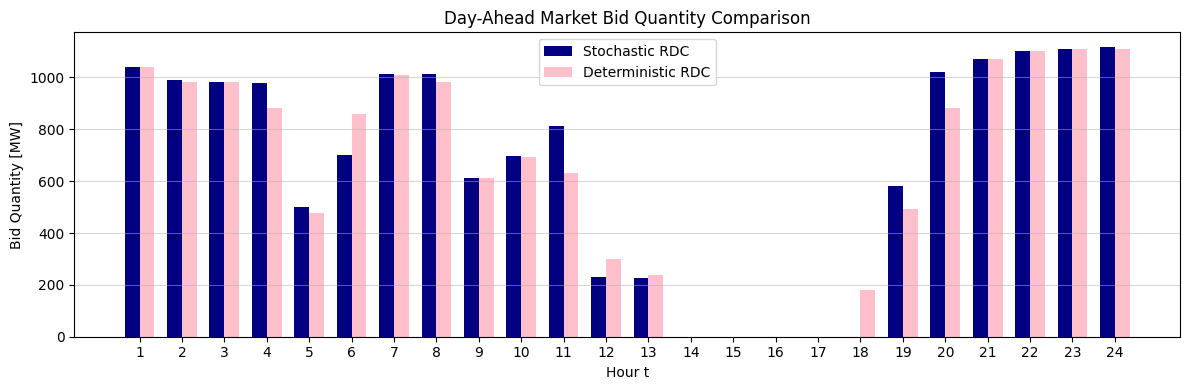

In [12]:
# ---------- p_bid 값 추출 ----------
# ---------- p_bid 값 추출 ----------
# SP (Stochastic RP 해 → Var.X 필요)
p_bid_SP = [p_bid[t].X for t in T]

# EV (Deterministic EV 해 → 이미 float 값이므로 .X 필요 없음)
p_bid_EV = [ev_sol["p_bid"][t] for t in T]
# ---------- 시각화 ----------
x = np.arange(len(T))  # 시간 축 (0~23)
width = 0.35           # 막대 폭

plt.figure(figsize=(12,4))
plt.bar(x - width/2, p_bid_SP, width, label="Stochastic RDC", color="navy")
plt.bar(x + width/2, p_bid_EV, width, label="Deterministic RDC", color="pink")

plt.xlabel("Hour t")
plt.ylabel("Bid Quantity [MW]")
plt.title("Day-Ahead Market Bid Quantity Comparison")
plt.xticks(x, T)   # x축 라벨을 Hour index로 표시
plt.legend()
plt.grid(True, axis="y", alpha=0.5)
plt.tight_layout()
plt.show()

In [13]:
print("DA_rev_RP =", DA_rev.getValue())
print("RT_rev_RP =", RT_rev.getValue())

DA_rev_RP = 919974.2536063954
RT_rev_RP = -99048.10022867503


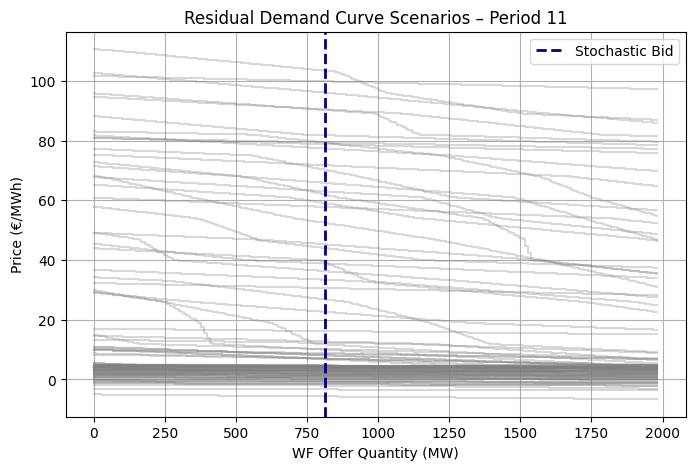

In [15]:
period = 11  # 보고 싶은 시간대

plt.figure(figsize=(8,5))

# --- 모든 RDC 시나리오 stepwise curve 그리기 ---
for w in W:
    q_steps, p_steps = [], []
    for b in valid_blocks_by_w.get((period,w), []):
        q_low  = qini_big[(period,b,w)]
        q_high = q_low + qmax_big[(period,b,w)]
        lam    = lambda_da_big[(period,b,w)]
        q_steps.extend([q_low, q_high])
        p_steps.extend([lam, lam])
    if p_steps:
        plt.step(q_steps, p_steps, where="post", alpha=0.3, color="gray")

# --- RP 해에서 선택한 p_bid 표시 ---
plt.axvline(p_bid_SP[period-1], color="navy", linestyle="--", lw=2, label="Stochastic Bid")

# --- Plot 꾸미기 ---
plt.xlabel("WF Offer Quantity (MW)")
plt.ylabel("Price (€/MWh)")
plt.title(f"Residual Demand Curve Scenarios – Period {period}")
plt.legend()
plt.grid(True)
plt.show()


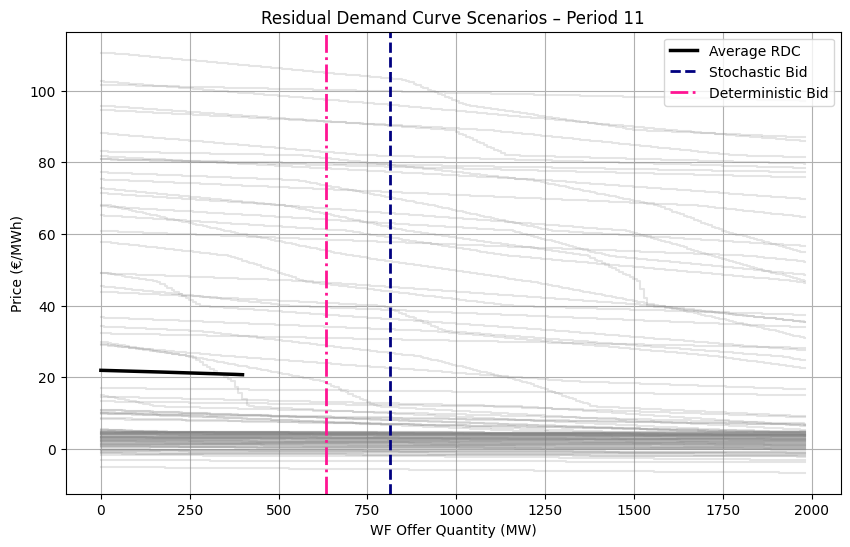

In [17]:
period = 11   # 확인할 시간대
w0 = 0       # 블록 경계 확인용 대표 시나리오 (stochastic용)

plt.figure(figsize=(10,6))

# --- 1) 모든 RDC 시나리오 stepwise curve ---
for w in W:
    q_steps, p_steps = [], []
    for b in valid_blocks_by_w.get((period,w), []):
        q_low  = qini_big[(period,b,w)]
        q_high = q_low + qmax_big[(period,b,w)]
        lam    = lambda_da_big[(period,b,w)]
        q_steps.extend([q_low, q_high])
        p_steps.extend([lam, lam])
    if p_steps:
        plt.step(q_steps, p_steps, where="post", alpha=0.2, color="gray")

# --- 2) 평균 RDC 계산 ---
q_grid = np.linspace(0, max(qini_big[(period,b,w)] + qmax_big[(period,b,w)]
                            for w in W for b in valid_blocks_by_w.get((period,w), [])), 200)

# 각 q에 대해 평균 가격 추정
avg_prices = []
for q in q_grid:
    lam_list = []
    for w in W:
        for b in valid_blocks_by_w.get((period,w), []):
            q_low  = qini_big[(period,b,w)]
            q_high = q_low + qmax_big[(period,b,w)]
            lam    = lambda_da_big[(period,b,w)]
            if q_low <= q < q_high:
                lam_list.append(lam)
                break
    avg_prices.append(np.mean(lam_list) if lam_list else np.nan)

plt.plot(q_grid, avg_prices, color="black", lw=2.5, label="Average RDC")

# --- 3) Stochastic 해 표시 ---
bid_q_sp = p_bid_SP[period-1]
plt.axvline(bid_q_sp, color="navy", linestyle="--", lw=2, label="Stochastic Bid")

# --- 4) Deterministic 해 표시 ---
bid_q_ev = p_bid_EV[period-1]
plt.axvline(bid_q_ev, color="deeppink", linestyle="-.", lw=2, label="Deterministic Bid")

# --- Plot 꾸미기 ---
plt.xlabel("WF Offer Quantity (MW)")
plt.ylabel("Price (€/MWh)")
plt.title(f"Residual Demand Curve Scenarios – Period {period}")
plt.legend()
plt.grid(True)
plt.show()


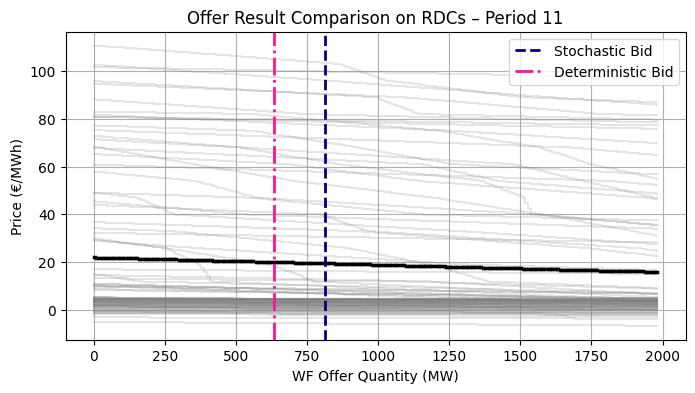

In [26]:
period = 11

plt.figure(figsize=(8,4))

# --- 1) 모든 RDC 시나리오 ---
for w in W:
    q_steps, p_steps = [], []
    for b in valid_blocks_by_w.get((period,w), []):
        q_low  = qini_big[(period,b,w)]
        q_high = q_low + qmax_big[(period,b,w)]
        lam    = lambda_da_big[(period,b,w)]
        q_steps.extend([q_low, q_high])
        p_steps.extend([lam, lam])
    if p_steps:
        plt.step(q_steps, p_steps, where="post", alpha=0.2, color="gray")

# --- 2) 평균 RDC (블록 단위 평균) ---
for b in set(b for w in W for b in valid_blocks_by_w.get((period,w), [])):
    q_low  = np.mean([qini_big[(period,b,w)] for w in W if (period,b,w) in qini_big])
    q_high = np.mean([qini_big[(period,b,w)] + qmax_big[(period,b,w)] for w in W if (period,b,w) in qmax_big])
    lam    = np.mean([lambda_da_big[(period,b,w)] for w in W if (period,b,w) in lambda_da_big])
    plt.step([q_low, q_high], [lam, lam], where="post", color="black", lw=2.5)

# --- 3) Stochastic / Deterministic 해 표시 ---
plt.axvline(p_bid_SP[period-1], color="navy", linestyle="--", lw=2, label="Stochastic Bid")
plt.axvline(p_bid_EV[period-1], color="deeppink", linestyle="-.", lw=2, label="Deterministic Bid")

plt.xlabel("WF Offer Quantity (MW)")
plt.ylabel("Price (€/MWh)")
plt.title(f"Offer Result Comparison on RDCs – Period {period}")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()
